# From Theory to Implementation: Data Preprocessing & Feature Selection

## Loan Prediction Dataset

**Course:** Machine Learning  
**Assignment Type:** Group Practical Assignment

### Group Members
### 1. Aayushi Sonkar - CSJMA23001390001
### 2.Aryan kumar -CSJMA23001390011
### 3.Sahil Kumar Yadav-CSJMA23001390038
### 4.Shubhash Verma -CSJMA23001390042


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("/content/loan_prediction.csv.csv")

In [57]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [58]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [59]:
df.shape

(614, 13)

In [60]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [61]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [63]:
df.nunique()

,0
Loan_ID,614
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10


In [64]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [65]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [66]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Part A — Problem and Dataset Understanding

### Problem Statement

The dataset represents a loan approval problem. The objective is to analyze applicant information and determine whether a loan application is likely to be approved or rejected.

### Objective

The main objective is to understand, clean, preprocess, transform, and select useful features from the dataset while implementing important preprocessing and feature-selection techniques from scratch.

### Target Variable

Loan_Status

- Y → Loan Approved
- N → Loan Not Approved

### Problem Type

Binary Classification

### Dataset Features

| Feature | Description | Data Type | Role |
|---|---|---|---|
| Loan_ID | Unique loan application identifier | Categorical/Identifier | Remove |
| Gender | Applicant gender | Categorical | Input |
| Married | Marital status | Categorical | Input |
| Dependents | Number of dependents | Categorical/Discrete | Input |
| Education | Education status | Categorical | Input |
| Self_Employed | Employment status | Categorical | Input |
| ApplicantIncome | Applicant income | Numerical | Input |
| CoapplicantIncome | Co-applicant income | Numerical | Input |
| LoanAmount | Loan amount | Numerical | Input |
| Loan_Amount_Term | Loan repayment term | Numerical/Discrete | Input |
| Credit_History | Credit history indicator | Discrete/Categorical | Input |
| Property_Area | Property location type | Categorical | Input |
| Loan_Status | Loan approval status | Categorical | Target |

In [67]:
income = df["ApplicantIncome"].dropna().tolist()

print("Number of observations:", len(income))
print("First 10 values:", income[:10])

Number of observations: 614
First 10 values: [5849, 4583, 3000, 2583, 6000, 5417, 2333, 3036, 4006, 12841]


In [68]:
total = 0

for x in income:
    total = total + x

mean_manual = total / len(income)

print("Manual Mean:", mean_manual)

Manual Mean: 5403.459283387622


In [69]:
mean_pandas = df["ApplicantIncome"].mean()

print("Manual Mean:", mean_manual)
print("Pandas Mean:", mean_pandas)

Manual Mean: 5403.459283387622
Pandas Mean: 5403.459283387622


In [70]:
minimum = income[0]
maximum = income[0]

for x in income:
    if x < minimum:
        minimum = x

    if x > maximum:
        maximum = x

print("Manual Minimum:", minimum)
print("Manual Maximum:", maximum)

Manual Minimum: 150
Manual Maximum: 81000


In [71]:
data_range = maximum - minimum

print("Manual Range:", data_range)

Manual Range: 80850


In [72]:
sorted_income = sorted(income)

n = len(sorted_income)

if n % 2 == 1:
    median_manual = sorted_income[n // 2]
else:
    middle1 = sorted_income[(n // 2) - 1]
    middle2 = sorted_income[n // 2]
    median_manual = (middle1 + middle2) / 2

print("Manual Median:", median_manual)

Manual Median: 3812.5


In [73]:
frequency = {}

for x in income:
    if x in frequency:
        frequency[x] = frequency[x] + 1
    else:
        frequency[x] = 1

mode_manual = None
highest_frequency = 0

for value, count in frequency.items():
    if count > highest_frequency:
        highest_frequency = count
        mode_manual = value

print("Manual Mode:", mode_manual)
print("Frequency:", highest_frequency)

Manual Mode: 2500
Frequency: 9


In [74]:
sum_squared_difference = 0

for x in income:
    difference = x - mean_manual
    squared_difference = difference ** 2
    sum_squared_difference = sum_squared_difference + squared_difference

variance_manual = sum_squared_difference / len(income)

print("Manual Variance:", variance_manual)

Manual Variance: 37259607.772772074


In [75]:
standard_deviation_manual = variance_manual ** 0.5

print("Manual Standard Deviation:", standard_deviation_manual)

Manual Standard Deviation: 6104.064856533888


In [76]:
variance_numpy = np.var(income)

print("Manual Variance:", variance_manual)
print("NumPy Variance:", variance_numpy)

Manual Variance: 37259607.772772074
NumPy Variance: 37259607.77277212


In [77]:
std_numpy = np.std(income)

print("Manual Standard Deviation:", standard_deviation_manual)
print("NumPy Standard Deviation:", std_numpy)

Manual Standard Deviation: 6104.064856533888
NumPy Standard Deviation: 6104.0648565338915


In [78]:
print("===== ApplicantIncome Statistics =====")
print("Minimum:", minimum)
print("Maximum:", maximum)
print("Range:", data_range)
print("Mean:", mean_manual)
print("Median:", median_manual)
print("Mode:", mode_manual)
print("Variance:", variance_manual)
print("Standard Deviation:", standard_deviation_manual)

===== ApplicantIncome Statistics =====
Minimum: 150
Maximum: 81000
Range: 80850
Mean: 5403.459283387622
Median: 3812.5
Mode: 2500
Variance: 37259607.772772074
Standard Deviation: 6104.064856533888


In [79]:
# B2 - Basic Statistics from Scratch

def calculate_statistics(column):
    # Remove missing values
    values = [x for x in column if pd.notna(x)]
    n = len(values)

    # Minimum and Maximum
    minimum = min(values)
    maximum = max(values)

    # Range
    data_range = maximum - minimum

    # Mean
    mean = sum(values) / n

    # Median
    sorted_values = sorted(values)

    if n % 2 == 0:
        median = (sorted_values[n//2 - 1] + sorted_values[n//2]) / 2
    else:
        median = sorted_values[n//2]

    # Mode
    frequency = {}

    for value in values:
        frequency[value] = frequency.get(value, 0) + 1

    max_frequency = max(frequency.values())
    modes = [value for value, count in frequency.items()
             if count == max_frequency]

    # Variance
    squared_deviations = [(x - mean) ** 2 for x in values]
    variance = sum(squared_deviations) / n

    # Standard Deviation
    standard_deviation = variance ** 0.5

    return {
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": data_range,
        "Mean": mean,
        "Median": median,
        "Mode": modes,
        "Variance": variance,
        "Standard Deviation": standard_deviation
    }


# Calculate statistics
coapplicant_stats = calculate_statistics(df["CoapplicantIncome"])
loanamount_stats = calculate_statistics(df["LoanAmount"])


print("===== CoapplicantIncome Statistics =====")
for key, value in coapplicant_stats.items():
    print(f"{key}: {value}")

print("\n===== LoanAmount Statistics =====")
for key, value in loanamount_stats.items():
    print(f"{key}: {value}")

===== CoapplicantIncome Statistics =====
Minimum: 0.0
Maximum: 41667.0
Range: 41667.0
Mean: 1621.245798027101
Median: 1188.5
Mode: [0.0]
Variance: 8548983.379106462
Standard Deviation: 2923.8644597700595

===== LoanAmount Statistics =====
Minimum: 9.0
Maximum: 700.0
Range: 691.0
Mean: 146.41216216216216
Median: 128.0
Mode: [120.0]
Variance: 7312.816608838567
Standard Deviation: 85.51500809120331


In [80]:
print("===== Pandas Verification =====")

print("\nCoapplicantIncome:")
print(df["CoapplicantIncome"].describe())

print("\nLoanAmount:")
print(df["LoanAmount"].describe())

===== Pandas Verification =====

CoapplicantIncome:
count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

LoanAmount:
count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64


### Interpretation

The ApplicantIncome has a mean of 5403.46 and a median of 3812.50. Since the mean is greater than the median, the feature appears to be right-skewed. Its large standard deviation of 6104.06 indicates substantial variation in applicant income.

CoapplicantIncome has a mean of 1621.25 and a median of 1188.50. The maximum value of 41667 is much larger than the median, indicating the presence of extreme values and a right-skewed distribution.

LoanAmount has a mean of 146.41 and a median of 128.00. The difference between mean and median also suggests right-skewness. The maximum loan amount of 700 is considerably higher than the median, indicating possible extreme observations.

The manually calculated statistics were verified using Pandas. Any difference in standard deviation is due to the different variance conventions: the manual calculation uses population variance (division by n), while Pandas `std()` uses sample variance (division by n-1) by default.

In [81]:
# Part C1 - Missing Value Analysis

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

missing_table

,Missing Values,Missing Percentage
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


In [82]:
# C2 - Values used for Missing Value Treatment

print("Gender Mode:", df["Gender"].mode()[0])
print("Married Mode:", df["Married"].mode()[0])
print("Dependents Mode:", df["Dependents"].mode()[0])
print("Self_Employed Mode:", df["Self_Employed"].mode()[0])

print("LoanAmount Median:", df["LoanAmount"].median())

print("Loan_Amount_Term Mode:", df["Loan_Amount_Term"].mode()[0])
print("Credit_History Mode:", df["Credit_History"].mode()[0])

Gender Mode: Male
Married Mode: Yes
Dependents Mode: 0
Self_Employed Mode: No
LoanAmount Median: 128.0
Loan_Amount_Term Mode: 360.0
Credit_History Mode: 1.0


In [83]:
# C2 - Missing Value Treatment From Scratch

# Make a copy of the original dataset
df_clean = df.copy()

# Calculate required replacement values
gender_mode = df_clean["Gender"].mode()[0]
married_mode = df_clean["Married"].mode()[0]
dependents_mode = df_clean["Dependents"].mode()[0]
self_employed_mode = df_clean["Self_Employed"].mode()[0]

loanamount_median = df_clean["LoanAmount"].median()

loan_term_mode = df_clean["Loan_Amount_Term"].mode()[0]
credit_history_mode = df_clean["Credit_History"].mode()[0]


# Manually replace missing values
df_clean["Gender"] = df_clean["Gender"].apply(
    lambda x: gender_mode if pd.isna(x) else x
)

df_clean["Married"] = df_clean["Married"].apply(
    lambda x: married_mode if pd.isna(x) else x
)

df_clean["Dependents"] = df_clean["Dependents"].apply(
    lambda x: dependents_mode if pd.isna(x) else x
)

df_clean["Self_Employed"] = df_clean["Self_Employed"].apply(
    lambda x: self_employed_mode if pd.isna(x) else x
)

df_clean["LoanAmount"] = df_clean["LoanAmount"].apply(
    lambda x: loanamount_median if pd.isna(x) else x
)

df_clean["Loan_Amount_Term"] = df_clean["Loan_Amount_Term"].apply(
    lambda x: loan_term_mode if pd.isna(x) else x
)

df_clean["Credit_History"] = df_clean["Credit_History"].apply(
    lambda x: credit_history_mode if pd.isna(x) else x
)

In [84]:
# Compare missing values before and after treatment

before_missing = df.isnull().sum()
after_missing = df_clean.isnull().sum()

comparison = pd.DataFrame({
    "Before Missing Values": before_missing,
    "After Missing Values": after_missing
})

comparison

,Before Missing Values,After Missing Values
Loan_ID,0,0
Gender,13,0
Married,3,0
Dependents,15,0
Education,0,0
Self_Employed,32,0
ApplicantIncome,0,0
CoapplicantIncome,0,0
LoanAmount,22,0
Loan_Amount_Term,14,0


### Missing Value Treatment — Interpretation

Missing values in categorical and discrete variables were replaced using mode imputation because the mode represents the most frequently occurring category/value.

LoanAmount was treated using median imputation because it is a numerical variable with a right-skewed distribution and potential extreme values. The median is less sensitive to extreme observations than the mean.

No observations were removed because the percentage of missing values in individual features was relatively small and the available observations contain useful information.

The primary missing-value treatment was implemented manually using basic Python logic rather than SimpleImputer.

In [85]:
# D1 - Duplicate Detection

duplicate_count = df_clean.duplicated().sum()

print("Original Records:", len(df_clean))
print("Duplicate Records:", duplicate_count)
print("Records After Treatment:", len(df_clean) - duplicate_count)

Original Records: 614
Duplicate Records: 0
Records After Treatment: 614


In [86]:
df_clean[df_clean.duplicated()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [87]:
# D2 - Check categorical values

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df_clean[column].unique())


===== Gender =====
['Male' 'Female']

===== Married =====
['No' 'Yes']

===== Dependents =====
['0' '1' '2' '3+']

===== Education =====
['Graduate' 'Not Graduate']

===== Self_Employed =====
['No' 'Yes']

===== Property_Area =====
['Urban' 'Rural' 'Semiurban']

===== Loan_Status =====
['Y' 'N']


In [88]:
# Check potentially invalid numerical values

numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    print(f"{column}: Min = {df_clean[column].min()}, Max = {df_clean[column].max()}")

ApplicantIncome: Min = 150, Max = 81000
CoapplicantIncome: Min = 0.0, Max = 41667.0
LoanAmount: Min = 9.0, Max = 700.0
Loan_Amount_Term: Min = 12.0, Max = 480.0
Credit_History: Min = 0.0, Max = 1.0


### Duplicate Detection — Interpretation

Duplicate observations were checked using the complete set of feature values. Duplicate records can cause certain observations to receive excessive importance during analysis or model training.

If a duplicate represents an accidental repeated record, it may be removed. However, duplicate-looking observations are not always errors because two different applicants may legitimately have identical feature values.

Therefore, duplicates were removed only if they were confirmed to be accidental duplicate observations.

### Invalid/Inconsistent Data — Interpretation

Categorical values and numerical ranges were examined for inconsistent or impossible values. The categorical variables were checked for spelling, capitalization, extra spaces, and unexpected categories.

Numerical variables were checked for impossible negative values and unreasonable ranges. Valid extreme values were not automatically removed because an extreme observation is not necessarily an error.

In [89]:
# D2 - Check categorical values for inconsistencies

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df_clean[column].unique())


===== Gender =====
['Male' 'Female']

===== Married =====
['No' 'Yes']

===== Dependents =====
['0' '1' '2' '3+']

===== Education =====
['Graduate' 'Not Graduate']

===== Self_Employed =====
['No' 'Yes']

===== Property_Area =====
['Urban' 'Rural' 'Semiurban']

===== Loan_Status =====
['Y' 'N']


In [90]:
# D1 - Duplicate Detection

duplicate_count = df_clean.duplicated().sum()

print("Original Records:", len(df_clean))
print("Duplicate Records:", duplicate_count)
print("Records After Treatment:", len(df_clean) - duplicate_count)

Original Records: 614
Duplicate Records: 0
Records After Treatment: 614


In [91]:
numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    print(f"{column}: Min = {df_clean[column].min()}, Max = {df_clean[column].max()}")

ApplicantIncome: Min = 150, Max = 81000
CoapplicantIncome: Min = 0.0, Max = 41667.0
LoanAmount: Min = 9.0, Max = 700.0
Loan_Amount_Term: Min = 12.0, Max = 480.0
Credit_History: Min = 0.0, Max = 1.0


### Numerical Data Validation — Interpretation

The numerical features were checked for impossible or invalid values. No negative income or loan amount values were found. Credit_History contains only 0 and 1, which are valid binary values. Loan_Amount_Term contains positive values.

Some observations have relatively high income or loan amounts. However, these values are not considered invalid merely because they are extreme. They will be examined separately during the outlier detection stage.

In [92]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df_clean[column].unique())


===== Gender =====
['Male' 'Female']

===== Married =====
['No' 'Yes']

===== Dependents =====
['0' '1' '2' '3+']

===== Education =====
['Graduate' 'Not Graduate']

===== Self_Employed =====
['No' 'Yes']

===== Property_Area =====
['Urban' 'Rural' 'Semiurban']

===== Loan_Status =====
['Y' 'N']


In [93]:
print("Duplicate Records:", df_clean.duplicated().sum())

Duplicate Records: 0


### Categorical Data Validation — Interpretation

The categorical variables were checked for inconsistent spellings, capitalization, and unexpected categories.

The observed categories were:

- Gender: Male, Female
- Married: Yes, No
- Dependents: 0, 1, 2, 3+
- Education: Graduate, Not Graduate
- Self_Employed: Yes, No
- Property_Area: Urban, Rural, Semiurban
- Loan_Status: Y, N

No obvious spelling, capitalization, or category inconsistencies were found.

### Duplicate Detection — Interpretation

The dataset contains 0 duplicate records. Therefore, no observations were removed during duplicate treatment.

Extreme numerical values were retained because an extreme value is not necessarily an invalid value. These observations will be examined separately using IQR and Z-score methods in the outlier analysis.

In [94]:
# E1 - Label Encoding From Scratch

df_encoded = df_clean.copy()

# Create mappings manually
gender_mapping = {
    "Female": 0,
    "Male": 1
}

married_mapping = {
    "No": 0,
    "Yes": 1
}

education_mapping = {
    "Not Graduate": 0,
    "Graduate": 1
}

self_employed_mapping = {
    "No": 0,
    "Yes": 1
}

loan_status_mapping = {
    "N": 0,
    "Y": 1
}

# Apply mappings
df_encoded["Gender"] = df_encoded["Gender"].map(gender_mapping)
df_encoded["Married"] = df_encoded["Married"].map(married_mapping)
df_encoded["Education"] = df_encoded["Education"].map(education_mapping)
df_encoded["Self_Employed"] = df_encoded["Self_Employed"].map(self_employed_mapping)
df_encoded["Loan_Status"] = df_encoded["Loan_Status"].map(loan_status_mapping)

print("Label Encoding completed successfully!")

Label Encoding completed successfully!


In [95]:
print("Gender Mapping:", gender_mapping)
print("Married Mapping:", married_mapping)
print("Education Mapping:", education_mapping)
print("Self_Employed Mapping:", self_employed_mapping)
print("Loan_Status Mapping:", loan_status_mapping)

Gender Mapping: {'Female': 0, 'Male': 1}
Married Mapping: {'No': 0, 'Yes': 1}
Education Mapping: {'Not Graduate': 0, 'Graduate': 1}
Self_Employed Mapping: {'No': 0, 'Yes': 1}
Loan_Status Mapping: {'N': 0, 'Y': 1}


In [96]:
df_encoded[
    ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]
].head(10)

,Gender,Married,Education,Self_Employed,Loan_Status
0,1,0,1,0,1
1,1,1,1,0,0
2,1,1,1,1,1
3,1,1,0,0,1
4,1,0,1,0,1
5,1,1,1,1,1
6,1,1,0,0,1
7,1,1,1,0,0
8,1,1,1,0,1
9,1,1,1,0,0


### E1 — Label Encoding

Label Encoding is a technique used to convert categorical values into numerical labels.

For example:

Female → 0
Male → 1

In this dataset, Label Encoding was applied to binary categorical variables such as Gender, Married, Education, Self_Employed, and Loan_Status.

The encoding mappings were created manually using Python dictionaries instead of directly using LabelEncoder.

### When is Label Encoding suitable?

Label Encoding is suitable for binary categorical variables and ordinal categories where the order of categories has meaningful interpretation.

### Limitation

For nominal categories, assigning numbers can create an artificial numerical relationship. For example, if Urban = 0, Rural = 1, and Semiurban = 2, a model may incorrectly interpret the numbers as having an ordered relationship. Therefore, One-Hot Encoding is more appropriate for nominal categories such as Property_Area.

In [97]:
# E2 - One-Hot Encoding From Scratch

df_onehot = df_encoded.copy()

# Property_Area categories
property_categories = ["Urban", "Rural", "Semiurban"]

# Create one-hot columns manually
for category in property_categories:
    column_name = "Property_Area_" + category

    df_onehot[column_name] = df_clean["Property_Area"].apply(
        lambda x: 1 if x == category else 0
    )


# Dependents categories
dependent_categories = ["0", "1", "2", "3+"]

for category in dependent_categories:
    column_name = "Dependents_" + category

    df_onehot[column_name] = df_clean["Dependents"].apply(
        lambda x: 1 if x == category else 0
    )


print("One-Hot Encoding completed successfully!")

One-Hot Encoding completed successfully!


In [98]:
df_onehot[
    [
        "Property_Area",
        "Property_Area_Urban",
        "Property_Area_Rural",
        "Property_Area_Semiurban",
        "Dependents",
        "Dependents_0",
        "Dependents_1",
        "Dependents_2",
        "Dependents_3+"
    ]
].head(10)

,Property_Area,Property_Area_Urban,Property_Area_Rural,Property_Area_Semiurban,Dependents,Dependents_0,Dependents_1,Dependents_2,Dependents_3+
0,Urban,1,0,0,0,1,0,0,0
1,Rural,0,1,0,1,0,1,0,0
2,Urban,1,0,0,0,1,0,0,0
3,Urban,1,0,0,0,1,0,0,0
4,Urban,1,0,0,0,1,0,0,0
5,Urban,1,0,0,2,0,0,1,0
6,Urban,1,0,0,0,1,0,0,0
7,Semiurban,0,0,1,3+,0,0,0,1
8,Urban,1,0,0,2,0,0,1,0
9,Semiurban,0,0,1,1,0,1,0,0


### E2 — One-Hot Encoding

One-Hot Encoding converts categorical values into separate binary columns.

For example, Property_Area contains three categories:

Urban, Rural, Semiurban

These were converted into:

Urban       → 1 0 0
Rural       → 0 1 0
Semiurban   → 0 0 1

One-Hot Encoding is useful for nominal categorical variables because it does not introduce an artificial numerical ordering between categories.

In this assignment, One-Hot Encoding was implemented from scratch using Python loops, conditions, and binary indicator columns instead of directly using OneHotEncoder or pandas get_dummies().

### Label Encoding vs One-Hot Encoding

Label Encoding represents categories using numerical labels such as 0 and 1. It is suitable for binary or ordinal categories.

One-Hot Encoding creates separate binary columns for each category. It is generally more suitable for nominal categories where no natural order exists.

In [99]:
# Library Verification for One-Hot Encoding

property_verified = pd.get_dummies(
    df_clean["Property_Area"],
    prefix="Property_Area"
).astype(int)

dependents_verified = pd.get_dummies(
    df_clean["Dependents"],
    prefix="Dependents"
).astype(int)

print("Property_Area verification:")
print(property_verified.head())

print("\nDependents verification:")
print(dependents_verified.head())

Property_Area verification:
   Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban
0                    0                        0                    1
1                    1                        0                    0
2                    0                        0                    1
3                    0                        0                    1
4                    0                        0                    1

Dependents verification:
   Dependents_0  Dependents_1  Dependents_2  Dependents_3+
0             1             0             0              0
1             0             1             0              0
2             1             0             0              0
3             1             0             0              0
4             1             0             0              0


In [100]:
# F1 - IQR Outlier Detection From Scratch

def calculate_iqr_outliers(column):
    # Remove missing values
    values = [x for x in column if pd.notna(x)]
    values = sorted(values)

    n = len(values)

    # Median function
    def median(data):
        m = len(data)

        if m % 2 == 0:
            return (data[m//2 - 1] + data[m//2]) / 2
        else:
            return data[m//2]

    # Q1 and Q3
    if n % 2 == 0:
        lower_half = values[:n//2]
        upper_half = values[n//2:]
    else:
        lower_half = values[:n//2]
        upper_half = values[n//2 + 1:]

    Q1 = median(lower_half)
    Q3 = median(upper_half)

    # IQR
    IQR = Q3 - Q1

    # Lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = [
        x for x in values
        if x < lower_bound or x > upper_bound
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, outliers


# Columns for outlier analysis
outlier_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

for column in outlier_columns:

    Q1, Q3, IQR, lower, upper, outliers = calculate_iqr_outliers(
        df_clean[column]
    )

    print(f"\n===== {column} =====")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))
    print("First 10 Outliers:", outliers[:10])


===== ApplicantIncome =====
Q1: 2876
Q3: 5800
IQR: 2924
Lower Bound: -1510.0
Upper Bound: 10186.0
Number of Outliers: 50
First 10 Outliers: [10408, 10416, 10513, 10750, 10833, 11000, 11146, 11250, 11417, 11500]

===== CoapplicantIncome =====
Q1: 0.0
Q3: 2302.0
IQR: 2302.0
Lower Bound: -3453.0
Upper Bound: 5755.0
Number of Outliers: 18
First 10 Outliers: [6250.0, 6666.0, 6667.0, 7101.0, 7166.0, 7210.0, 7250.0, 7750.0, 7873.0, 8106.0]

===== LoanAmount =====
Q1: 100.0
Q3: 165.0
IQR: 65.0
Lower Bound: 2.5
Upper Bound: 262.5
Number of Outliers: 41
First 10 Outliers: [265.0, 267.0, 275.0, 275.0, 275.0, 279.0, 280.0, 286.0, 290.0, 292.0]


In [101]:
# F2 - Z-Score Outlier Detection From Scratch

def calculate_zscore_outliers(column):
    values = [x for x in column if pd.notna(x)]

    # Mean
    mean = sum(values) / len(values)

    # Population variance
    variance = sum((x - mean) ** 2 for x in values) / len(values)

    # Standard deviation
    std = variance ** 0.5

    # Calculate Z-scores
    z_scores = []

    for x in values:
        z = (x - mean) / std
        z_scores.append(z)

    # Outliers where |Z| > 3
    outliers = [
        x for x, z in zip(values, z_scores)
        if abs(z) > 3
    ]

    return mean, std, z_scores, outliers


for column in outlier_columns:

    mean, std, z_scores, outliers = calculate_zscore_outliers(
        df_clean[column]
    )

    print(f"\n===== {column} =====")
    print("Mean:", mean)
    print("Standard Deviation:", std)
    print("Number of Z-score Outliers:", len(outliers))
    print("First 10 Outliers:", outliers[:10])


===== ApplicantIncome =====
Mean: 5403.459283387622
Standard Deviation: 6104.0648565338915
Number of Z-score Outliers: 8
First 10 Outliers: [23803, 39999, 51763, 33846, 39147, 63337, 81000, 37719]

===== CoapplicantIncome =====
Mean: 1621.245798027101
Standard Deviation: 2923.8644597700595
Number of Z-score Outliers: 6
First 10 Outliers: [10968.0, 11300.0, 20000.0, 20000.0, 33837.0, 41667.0]

===== LoanAmount =====
Mean: 145.75244299674267
Standard Deviation: 84.03871423798937
Number of Z-score Outliers: 15
First 10 Outliers: [650.0, 600.0, 700.0, 495.0, 436.0, 480.0, 490.0, 570.0, 405.0, 500.0]


In [102]:
# F1 - IQR Outlier Detection From Scratch

def calculate_iqr_outliers(column):
    # Remove missing values
    values = [x for x in column if pd.notna(x)]
    values = sorted(values)

    n = len(values)

    # Median function
    def median(data):
        m = len(data)
        if m % 2 == 0:
            return (data[m//2 - 1] + data[m//2]) / 2
        else:
            return data[m//2]

    # Split into lower and upper halves
    if n % 2 == 0:
        lower_half = values[:n//2]
        upper_half = values[n//2:]
    else:
        lower_half = values[:n//2]
        upper_half = values[n//2 + 1:]

    Q1 = median(lower_half)
    Q3 = median(upper_half)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = [
        x for x in values
        if x < lower_bound or x > upper_bound
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, outliers


# Apply to selected numerical columns

for column in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:

    Q1, Q3, IQR, lower, upper, outliers = calculate_iqr_outliers(
        df_clean[column]
    )

    print(f"\n===== {column} =====")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of IQR Outliers:", len(outliers))
    print("First 10 Outliers:", outliers[:10])


===== ApplicantIncome =====
Q1: 2876
Q3: 5800
IQR: 2924
Lower Bound: -1510.0
Upper Bound: 10186.0
Number of IQR Outliers: 50
First 10 Outliers: [10408, 10416, 10513, 10750, 10833, 11000, 11146, 11250, 11417, 11500]

===== CoapplicantIncome =====
Q1: 0.0
Q3: 2302.0
IQR: 2302.0
Lower Bound: -3453.0
Upper Bound: 5755.0
Number of IQR Outliers: 18
First 10 Outliers: [6250.0, 6666.0, 6667.0, 7101.0, 7166.0, 7210.0, 7250.0, 7750.0, 7873.0, 8106.0]

===== LoanAmount =====
Q1: 100.0
Q3: 165.0
IQR: 65.0
Lower Bound: 2.5
Upper Bound: 262.5
Number of IQR Outliers: 41
First 10 Outliers: [265.0, 267.0, 275.0, 275.0, 275.0, 279.0, 280.0, 286.0, 290.0, 292.0]


In [103]:
# F2 - Compare IQR and Z-score Outliers

print("===== IQR vs Z-score Comparison =====")

for column in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:

    # IQR outliers
    Q1, Q3, IQR, lower, upper, iqr_outliers = calculate_iqr_outliers(
        df_clean[column]
    )

    # Z-score outliers
    values = df_clean[column].dropna().tolist()

    mean = sum(values) / len(values)

    squared_sum = 0
    for x in values:
        squared_sum += (x - mean) ** 2

    std = (squared_sum / len(values)) ** 0.5

    z_outliers = [
        x for x in values
        if abs((x - mean) / std) > 3
    ]

    print(f"\n===== {column} =====")
    print("IQR Outliers:", len(iqr_outliers))
    print("Z-score Outliers:", len(z_outliers))
    print("IQR First 10:", iqr_outliers[:10])
    print("Z-score First 10:", z_outliers[:10])

===== IQR vs Z-score Comparison =====

===== ApplicantIncome =====
IQR Outliers: 50
Z-score Outliers: 8
IQR First 10: [10408, 10416, 10513, 10750, 10833, 11000, 11146, 11250, 11417, 11500]
Z-score First 10: [23803, 39999, 51763, 33846, 39147, 63337, 81000, 37719]

===== CoapplicantIncome =====
IQR Outliers: 18
Z-score Outliers: 6
IQR First 10: [6250.0, 6666.0, 6667.0, 7101.0, 7166.0, 7210.0, 7250.0, 7750.0, 7873.0, 8106.0]
Z-score First 10: [10968.0, 11300.0, 20000.0, 20000.0, 33837.0, 41667.0]

===== LoanAmount =====
IQR Outliers: 41
Z-score Outliers: 15
IQR First 10: [265.0, 267.0, 275.0, 275.0, 275.0, 279.0, 280.0, 286.0, 290.0, 292.0]
Z-score First 10: [650.0, 600.0, 700.0, 495.0, 436.0, 480.0, 490.0, 570.0, 405.0, 500.0]


In [104]:
# G1 - Log Transformation From Scratch

import math

# ApplicantIncome
applicant_income_log = []

for x in df_clean["ApplicantIncome"]:
    applicant_income_log.append(math.log1p(x))

# LoanAmount
loan_amount_log = []

for x in df_clean["LoanAmount"]:
    loan_amount_log.append(math.log1p(x))

# Add transformed columns
df_clean["ApplicantIncome_Log"] = applicant_income_log
df_clean["LoanAmount_Log"] = loan_amount_log

print("Log transformation completed successfully!")

print("\nOriginal ApplicantIncome - First 10:")
print(df_clean["ApplicantIncome"].head(10).tolist())

print("\nLog Transformed ApplicantIncome - First 10:")
print(df_clean["ApplicantIncome_Log"].head(10).tolist())

print("\nOriginal LoanAmount - First 10:")
print(df_clean["LoanAmount"].head(10).tolist())

print("\nLog Transformed LoanAmount - First 10:")
print(df_clean["LoanAmount_Log"].head(10).tolist())

Log transformation completed successfully!

Original ApplicantIncome - First 10:
[5849, 4583, 3000, 2583, 6000, 5417, 2333, 3036, 4006, 12841]

Log Transformed ApplicantIncome - First 10:
[8.674196940225903, 8.430327258394575, 8.006700845440367, 7.857093864902493, 8.699681400989514, 8.59748202264504, 7.755338812846501, 8.01862546504575, 8.295798110636145, 9.460476328353995]

Original LoanAmount - First 10:
[128.0, 128.0, 66.0, 120.0, 141.0, 267.0, 95.0, 158.0, 168.0, 349.0]

Log Transformed LoanAmount - First 10:
[4.859812404361672, 4.859812404361672, 4.204692619390966, 4.795790545596741, 4.955827057601261, 5.5909869805108565, 4.564348191467836, 5.0689042022202315, 5.1298987149230735, 5.857933154483459]


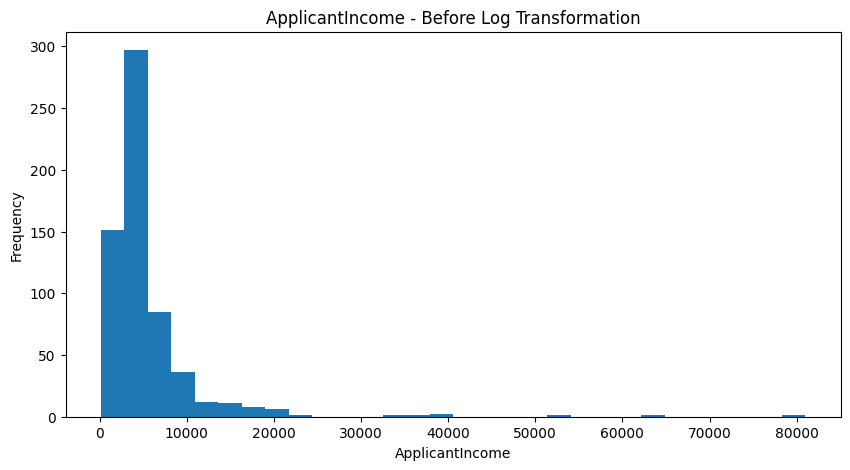

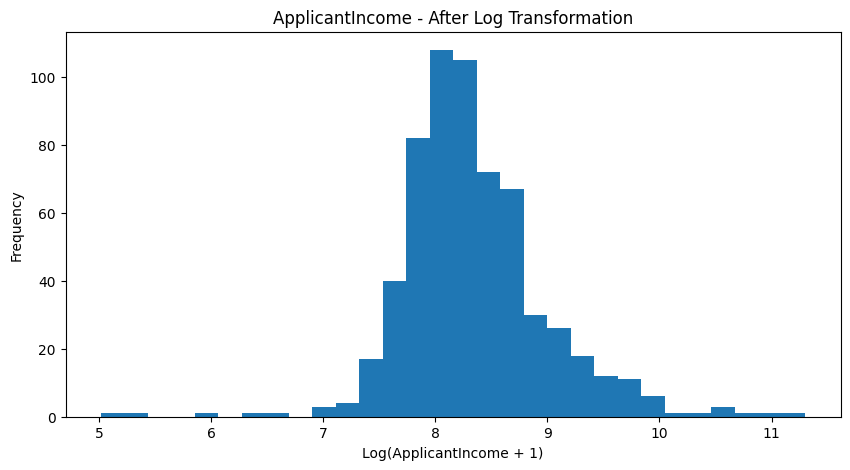

In [105]:
# G2 - Distribution Before and After Log Transformation

plt.figure(figsize=(10, 5))

plt.hist(df_clean["ApplicantIncome"], bins=30)
plt.title("ApplicantIncome - Before Log Transformation")
plt.xlabel("ApplicantIncome")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))

plt.hist(df_clean["ApplicantIncome_Log"], bins=30)
plt.title("ApplicantIncome - After Log Transformation")
plt.xlabel("Log(ApplicantIncome + 1)")
plt.ylabel("Frequency")
plt.show()

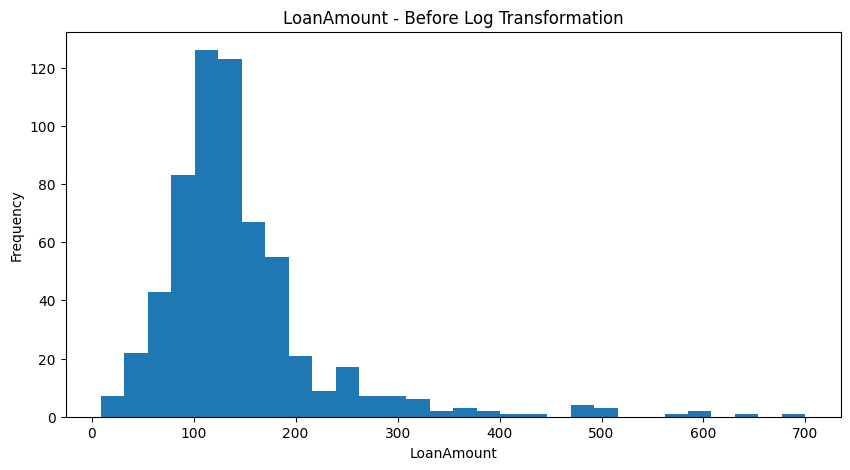

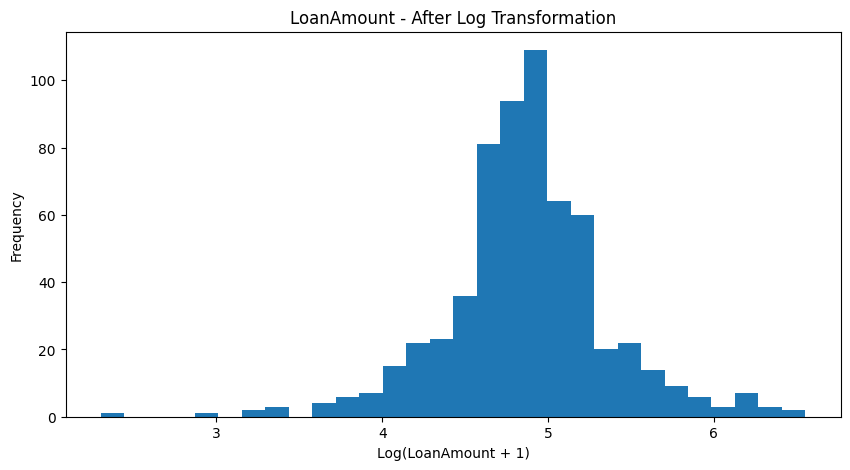

In [106]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean["LoanAmount"], bins=30)
plt.title("LoanAmount - Before Log Transformation")
plt.xlabel("LoanAmount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))

plt.hist(df_clean["LoanAmount_Log"], bins=30)
plt.title("LoanAmount - After Log Transformation")
plt.xlabel("Log(LoanAmount + 1)")
plt.ylabel("Frequency")
plt.show()

In [107]:
# H1 - Min-Max Normalization From Scratch

def min_max_normalize(column):
    values = column.tolist()

    minimum = min(values)
    maximum = max(values)

    normalized = []

    for x in values:
        value = (x - minimum) / (maximum - minimum)
        normalized.append(value)

    return normalized


df_scaled = df_clean.copy()

df_scaled["ApplicantIncome_MinMax"] = min_max_normalize(
    df_clean["ApplicantIncome"]
)

df_scaled["LoanAmount_MinMax"] = min_max_normalize(
    df_clean["LoanAmount"]
)

df_scaled["CoapplicantIncome_MinMax"] = min_max_normalize(
    df_clean["CoapplicantIncome"]
)

print("===== Min-Max Normalization =====")
print(df_scaled[
    [
        "ApplicantIncome",
        "ApplicantIncome_MinMax",
        "LoanAmount",
        "LoanAmount_MinMax",
        "CoapplicantIncome",
        "CoapplicantIncome_MinMax"
    ]
].head(10))

===== Min-Max Normalization =====
   ApplicantIncome  ApplicantIncome_MinMax  LoanAmount  LoanAmount_MinMax  \
0             5849                0.070489       128.0           0.172214   
1             4583                0.054830       128.0           0.172214   
2             3000                0.035250        66.0           0.082489   
3             2583                0.030093       120.0           0.160637   
4             6000                0.072356       141.0           0.191027   
5             5417                0.065145       267.0           0.373372   
6             2333                0.027001        95.0           0.124457   
7             3036                0.035696       158.0           0.215630   
8             4006                0.047693       168.0           0.230101   
9            12841                0.156970       349.0           0.492041   

   CoapplicantIncome  CoapplicantIncome_MinMax  
0                0.0                  0.000000  
1             1508.0

In [108]:
print("ApplicantIncome Min-Max Range:",
      df_scaled["ApplicantIncome_MinMax"].min(),
      "to",
      df_scaled["ApplicantIncome_MinMax"].max())

print("LoanAmount Min-Max Range:",
      df_scaled["LoanAmount_MinMax"].min(),
      "to",
      df_scaled["LoanAmount_MinMax"].max())

print("CoapplicantIncome Min-Max Range:",
      df_scaled["CoapplicantIncome_MinMax"].min(),
      "to",
      df_scaled["CoapplicantIncome_MinMax"].max())

ApplicantIncome Min-Max Range: 0.0 to 1.0
LoanAmount Min-Max Range: 0.0 to 1.0
CoapplicantIncome Min-Max Range: 0.0 to 1.0


In [109]:
# H2 - Standardization From Scratch

def standardize(column):

    values = column.tolist()

    mean = sum(values) / len(values)

    squared_sum = 0

    for x in values:
        squared_sum += (x - mean) ** 2

    std = (squared_sum / len(values)) ** 0.5

    standardized = []

    for x in values:
        z = (x - mean) / std
        standardized.append(z)

    return standardized


df_scaled["ApplicantIncome_Standardized"] = standardize(
    df_clean["ApplicantIncome"]
)

df_scaled["LoanAmount_Standardized"] = standardize(
    df_clean["LoanAmount"]
)

df_scaled["CoapplicantIncome_Standardized"] = standardize(
    df_clean["CoapplicantIncome"]
)

print("===== Standardization =====")

print(df_scaled[
    [
        "ApplicantIncome_Standardized",
        "LoanAmount_Standardized",
        "CoapplicantIncome_Standardized"
    ]
].head(10))

===== Standardization =====
   ApplicantIncome_Standardized  LoanAmount_Standardized  \
0                      0.072991                -0.211241   
1                     -0.134412                -0.211241   
2                     -0.393747                -0.948996   
3                     -0.462062                -0.306435   
4                      0.097728                -0.056551   
5                      0.002218                 1.442758   
6                     -0.503019                -0.603917   
7                     -0.387850                 0.145737   
8                     -0.228939                 0.264730   
9                      1.218457                 2.418499   

   CoapplicantIncome_Standardized  
0                       -0.554487  
1                       -0.038732  
2                       -0.554487  
3                        0.251980  
4                       -0.554487  
5                        0.880600  
6                       -0.035995  
7                      

In [110]:
print("ApplicantIncome:")
print("Mean:", df_scaled["ApplicantIncome_Standardized"].mean())
print("Std:", df_scaled["ApplicantIncome_Standardized"].std())

print("\nLoanAmount:")
print("Mean:", df_scaled["LoanAmount_Standardized"].mean())
print("Std:", df_scaled["LoanAmount_Standardized"].std())

print("\nCoapplicantIncome:")
print("Mean:", df_scaled["CoapplicantIncome_Standardized"].mean())
print("Std:", df_scaled["CoapplicantIncome_Standardized"].std())

ApplicantIncome:
Mean: -2.8930893149841213e-17
Std: 1.000815328305033

LoanAmount:
Mean: -2.025162520488885e-17
Std: 1.0008153283050327

CoapplicantIncome:
Mean: -8.679267944952363e-18
Std: 1.0008153283050323


In [111]:
# I1 - Manual Train-Test Split From Scratch

import random

# Reset index so that row numbers are continuous
data = df_scaled.reset_index(drop=True)

# Total number of records
n = len(data)

# Create row indices
indices = list(range(n))

# Fixed seed for reproducibility
random.seed(42)

# Shuffle indices manually
random.shuffle(indices)

# 80% training
train_size = int(0.80 * n)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create train and test datasets
train_data = data.iloc[train_indices].reset_index(drop=True)
test_data = data.iloc[test_indices].reset_index(drop=True)

print("Total Records:", n)
print("Training Records:", len(train_data))
print("Testing Records:", len(test_data))

Total Records: 614
Training Records: 491
Testing Records: 123


In [112]:
print("\n===== Train-Test Split Verification =====")

print("Training Percentage:",
      (len(train_data) / n) * 100)

print("Testing Percentage:",
      (len(test_data) / n) * 100)

print("\nTraining Shape:", train_data.shape)
print("Testing Shape:", test_data.shape)


===== Train-Test Split Verification =====
Training Percentage: 79.96742671009773
Testing Percentage: 20.03257328990228

Training Shape: (491, 21)
Testing Shape: (123, 21)


In [113]:
print("===== Target Distribution =====")

print("\nTraining Set:")
print(train_data["Loan_Status"].value_counts())

print("\nTesting Set:")
print(test_data["Loan_Status"].value_counts())

===== Target Distribution =====

Training Set:
Loan_Status
Y    333
N    158
Name: count, dtype: int64

Testing Set:
Loan_Status
Y    89
N    34
Name: count, dtype: int64


In [114]:
# M1 - Variance Calculation From Scratch

variance_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

variance_results = {}

for column in variance_features:

    values = df_clean[column].dropna().tolist()

    mean = sum(values) / len(values)

    squared_sum = 0

    for x in values:
        squared_sum += (x - mean) ** 2

    variance = squared_sum / len(values)

    variance_results[column] = variance

    print(f"{column}: Variance = {variance}")

ApplicantIncome: Variance = 37259607.772772074
CoapplicantIncome: Variance = 8548983.37910648
LoanAmount: Variance = 7062.505490774439
Loan_Amount_Term: Variance = 4144.287578648042
Credit_History: Variance = 0.12394030705896189


In [115]:
# Create variance summary table

variance_table = pd.DataFrame(
    list(variance_results.items()),
    columns=["Feature", "Variance"]
)

variance_table

,Feature,Variance
0,ApplicantIncome,3.725961e+07
1,CoapplicantIncome,8.548983e+06
2,LoanAmount,7.062505e+03
3,Loan_Amount_Term,4.144288e+03
4,Credit_History,1.239403e-01


### M1 — Variance Threshold: Interpretation

Variance measures how much a feature varies across observations.

A zero-variance feature has the same value for every observation and provides no discriminatory information.

In this dataset, none of the investigated numerical/discrete features has zero variance. Credit_History has relatively low variance because it is a binary feature, but it is retained because low variance alone does not imply that the feature is useless.

The final feature-selection decision will also consider other techniques such as Pearson Correlation, Chi-Square, ANOVA, and Mutual Information.

In [116]:
# M2 - Pearson Correlation From Scratch

def pearson_correlation(x, y):

    # Remove pairs containing missing values
    pairs = [
        (a, b)
        for a, b in zip(x, y)
        if pd.notna(a) and pd.notna(b)
    ]

    x_values = [pair[0] for pair in pairs]
    y_values = [pair[1] for pair in pairs]

    x_mean = sum(x_values) / len(x_values)
    y_mean = sum(y_values) / len(y_values)

    numerator = 0
    x_squared = 0
    y_squared = 0

    for a, b in zip(x_values, y_values):

        x_diff = a - x_mean
        y_diff = b - y_mean

        numerator += x_diff * y_diff
        x_squared += x_diff ** 2
        y_squared += y_diff ** 2

    denominator = (x_squared * y_squared) ** 0.5

    return numerator / denominator


features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

print("===== Pearson Correlation From Scratch =====")

for i in range(len(features)):
    for j in range(i + 1, len(features)):

        feature1 = features[i]
        feature2 = features[j]

        correlation = pearson_correlation(
            df_clean[feature1],
            df_clean[feature2]
        )

        print(
            f"{feature1} vs {feature2}: "
            f"{correlation:.4f}"
        )

===== Pearson Correlation From Scratch =====
ApplicantIncome vs CoapplicantIncome: -0.1166
ApplicantIncome vs LoanAmount: 0.5652
CoapplicantIncome vs LoanAmount: 0.1892


In [117]:
# M2 - Pearson Correlation Matrix

pearson_matrix = pd.DataFrame(index=features, columns=features)

for feature1 in features:
    for feature2 in features:
        if feature1 == feature2:
            pearson_matrix.loc[feature1, feature2] = 1.0
        else:
            pearson_matrix.loc[feature1, feature2] = pearson_correlation(
                df_clean[feature1],
                df_clean[feature2]
            )

pearson_matrix = pearson_matrix.astype(float)

print("Pearson Correlation Matrix:")
display(pearson_matrix)

Pearson Correlation Matrix:


,ApplicantIncome,CoapplicantIncome,LoanAmount
ApplicantIncome,1.000000,-0.116605,0.565181
CoapplicantIncome,-0.116605,1.000000,0.189218
LoanAmount,0.565181,0.189218,1.000000


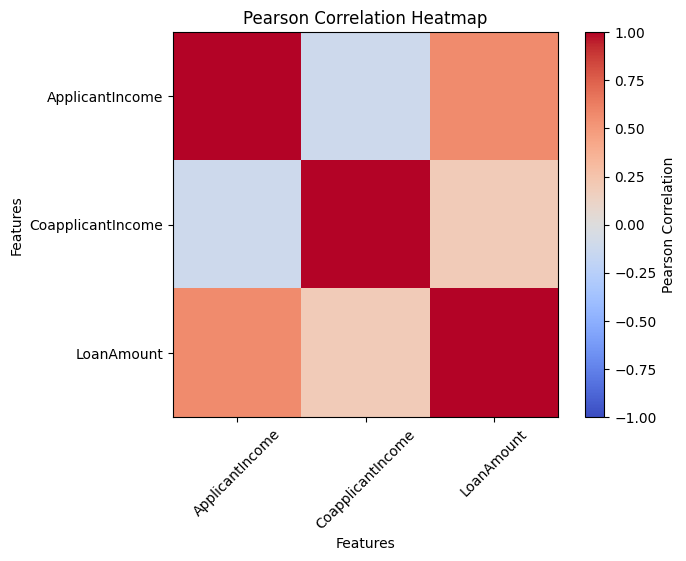

In [118]:
plt.figure(figsize=(7, 5))

plt.imshow(pearson_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)

plt.colorbar(label="Pearson Correlation")
plt.title("Pearson Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [119]:
print("===== Pandas Verification =====")
display(df_clean[features].corr())

===== Pandas Verification =====


,ApplicantIncome,CoapplicantIncome,LoanAmount
ApplicantIncome,1.000000,-0.116605,0.565181
CoapplicantIncome,-0.116605,1.000000,0.189218
LoanAmount,0.565181,0.189218,1.000000


### M2 — Pearson Correlation Interpretation

ApplicantIncome and LoanAmount show a moderate positive correlation of approximately 0.5652. This suggests that applicants with higher income tend to have higher loan amounts, although the relationship is not perfect.

ApplicantIncome and CoapplicantIncome show a weak negative correlation of approximately -0.1166, indicating very little linear relationship.

CoapplicantIncome and LoanAmount show a weak positive correlation of approximately 0.1892.

No pair shows extremely high correlation, so there is no strong evidence of severe feature redundancy based on Pearson correlation alone.

In [120]:
# M3 - Chi-Square Test From Scratch

def chi_square_manual(feature, target):

    # Unique categories
    feature_categories = feature.dropna().unique()
    target_categories = target.dropna().unique()

    # Create observed frequency table
    observed = {}

    for f_cat in feature_categories:
        observed[f_cat] = {}

        for t_cat in target_categories:
            count = 0

            for f, t in zip(feature, target):
                if pd.notna(f) and pd.notna(t):
                    if f == f_cat and t == t_cat:
                        count += 1

            observed[f_cat][t_cat] = count

    # Row totals
    row_totals = {}
    for f_cat in feature_categories:
        row_totals[f_cat] = sum(observed[f_cat].values())

    # Column totals
    column_totals = {}
    for t_cat in target_categories:
        column_totals[t_cat] = sum(
            observed[f_cat][t_cat]
            for f_cat in feature_categories
        )

    grand_total = sum(row_totals.values())

    # Calculate Chi-Square
    chi_square = 0

    expected = {}

    for f_cat in feature_categories:

        expected[f_cat] = {}

        for t_cat in target_categories:

            E = (
                row_totals[f_cat] *
                column_totals[t_cat]
            ) / grand_total

            O = observed[f_cat][t_cat]

            expected[f_cat][t_cat] = E

            chi_square += ((O - E) ** 2) / E

    # Degrees of freedom
    df_value = (
        (len(feature_categories) - 1) *
        (len(target_categories) - 1)
    )

    return observed, expected, chi_square, df_value


# Example: Gender vs Loan_Status

observed, expected, chi_value, degrees_freedom = chi_square_manual(
    df_clean["Gender"],
    df_clean["Loan_Status"]
)

print("===== Gender vs Loan_Status =====")

print("\nObserved Frequencies:")
print(pd.DataFrame(observed).T)

print("\nExpected Frequencies:")
print(pd.DataFrame(expected).T)

print("\nChi-Square Statistic:", chi_value)
print("Degrees of Freedom:", degrees_freedom)

===== Gender vs Loan_Status =====

Observed Frequencies:
          Y    N
Male    347  155
Female   75   37

Expected Frequencies:
                 Y           N
Male    345.022801  156.977199
Female   76.977199   35.022801

Chi-Square Statistic: 0.19864165509874282
Degrees of Freedom: 1


In [121]:
categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History"
]

for feature in categorical_features:

    observed, expected, chi_value, df_value = chi_square_manual(
        df_clean[feature],
        df_clean["Loan_Status"]
    )

    print(
        f"{feature}: "
        f"Chi-Square = {chi_value:.4f}, "
        f"df = {df_value}"
    )

Gender: Chi-Square = 0.1986, df = 1
Married: Chi-Square = 5.1381, df = 1
Education: Chi-Square = 4.5289, df = 1
Self_Employed: Chi-Square = 0.0084, df = 1
Property_Area: Chi-Square = 12.2976, df = 2
Credit_History: Chi-Square = 179.4113, df = 1


In [122]:
# M3 - Library Verification

from scipy.stats import chi2_contingency

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df_clean[feature],
        df_clean["Loan_Status"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(
        f"{feature}: "
        f"Chi-Square = {chi2:.4f}, "
        f"p-value = {p_value:.6f}, "
        f"df = {dof}"
    )

Gender: Chi-Square = 0.1109, p-value = 0.739146, df = 1
Married: Chi-Square = 4.7319, p-value = 0.029609, df = 1
Education: Chi-Square = 4.0915, p-value = 0.043100, df = 1
Self_Employed: Chi-Square = 0.0000, p-value = 1.000000, df = 1
Property_Area: Chi-Square = 12.2976, p-value = 0.002136, df = 2
Credit_History: Chi-Square = 176.1146, p-value = 0.000000, df = 1


### M3 — Chi-Square Interpretation

The Chi-Square test was used to investigate the relationship between categorical/discrete input features and the categorical target Loan_Status.

Credit_History produced the largest Chi-Square statistic, indicating a strong association with loan approval status. Property_Area also showed a relatively stronger association.

Gender and Self_Employed produced very small Chi-Square statistics, suggesting weak association with Loan_Status in this dataset.

The manually calculated Chi-Square statistics were verified using scipy.stats.chi2_contingency.

In [123]:
# M4 - ANOVA F-Test From Scratch

def anova_manual(feature, target):

    # Create groups based on target
    groups = {}

    for x, y in zip(feature, target):
        if pd.notna(x) and pd.notna(y):

            if y not in groups:
                groups[y] = []

            groups[y].append(x)

    # Overall mean
    all_values = []

    for group in groups.values():
        all_values.extend(group)

    overall_mean = sum(all_values) / len(all_values)

    # Between-group Sum of Squares
    between_ss = 0

    for group in groups.values():

        group_mean = sum(group) / len(group)

        between_ss += len(group) * (
            group_mean - overall_mean
        ) ** 2

    # Within-group Sum of Squares
    within_ss = 0

    for group in groups.values():

        group_mean = sum(group) / len(group)

        for x in group:
            within_ss += (x - group_mean) ** 2

    # Degrees of freedom
    number_of_groups = len(groups)
    total_observations = len(all_values)

    df_between = number_of_groups - 1
    df_within = total_observations - number_of_groups

    # Mean Squares
    mean_square_between = between_ss / df_between
    mean_square_within = within_ss / df_within

    # F-statistic
    f_statistic = mean_square_between / mean_square_within

    return (
        groups,
        overall_mean,
        between_ss,
        within_ss,
        df_between,
        df_within,
        f_statistic
    )


anova_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

for feature in anova_features:

    result = anova_manual(
        df_clean[feature],
        df_clean["Loan_Status"]
    )

    groups, overall_mean, between_ss, within_ss, df_b, df_w, f_value = result

    print(f"\n===== {feature} =====")

    print("Overall Mean:", overall_mean)

    for group_name, values in groups.items():
        print(
            f"Group {group_name}: "
            f"Count = {len(values)}, "
            f"Mean = {sum(values)/len(values):.4f}"
        )

    print("Between-group SS:", between_ss)
    print("Within-group SS:", within_ss)
    print("Between-group df:", df_b)
    print("Within-group df:", df_w)
    print("F-statistic:", f_value)


===== ApplicantIncome =====
Overall Mean: 5403.459283387622
Group Y: Count = 422, Mean = 5384.0687
Group N: Count = 192, Mean = 5446.0781
Between-group SS: 507411.64685068897
Within-group SS: 22876891760.835224
Between-group df: 1
Within-group df: 612
F-statistic: 0.013574218522301743

===== CoapplicantIncome =====
Overall Mean: 1621.245798027101
Group Y: Count = 422, Mean = 1504.5164
Group N: Count = 192, Mean = 1877.8073
Between-group SS: 18388237.290494278
Within-group SS: 5230687557.480881
Between-group df: 1
Within-group df: 612
F-statistic: 2.1514573558666683

===== LoanAmount =====
Overall Mean: 145.75244299674267
Group Y: Count = 422, Mean = 143.8697
Group N: Count = 192, Mean = 149.8906
Between-group SS: 4783.836456950403
Within-group SS: 4331594.534878554
Between-group df: 1
Within-group df: 612
F-statistic: 0.675896113562654


In [124]:
# M4 - ANOVA Library Verification

from scipy.stats import f_oneway

for feature in anova_features:

    approved = df_clean[
        df_clean["Loan_Status"] == "Y"
    ][feature].dropna()

    rejected = df_clean[
        df_clean["Loan_Status"] == "N"
    ][feature].dropna()

    f_value, p_value = f_oneway(
        approved,
        rejected
    )

    print(
        f"{feature}: "
        f"F-statistic = {f_value:.4f}, "
        f"p-value = {p_value:.6f}"
    )

ApplicantIncome: F-statistic = 0.0136, p-value = 0.907288
CoapplicantIncome: F-statistic = 2.1515, p-value = 0.142948
LoanAmount: F-statistic = 0.6759, p-value = 0.411324


### M4 — ANOVA F-Test Interpretation

ANOVA F-Test was used to examine whether the means of numerical features differ significantly between the approved and rejected loan groups.

All three numerical features have p-values greater than 0.05. Therefore, at the 5% significance level, there is insufficient statistical evidence that their group means differ significantly based on this ANOVA analysis.

ANOVA results alone were not used to remove features. The final feature-selection decision will consider multiple techniques and the practical importance of each feature.

In [125]:
# M5 - Mutual Information From Scratch

import math

def entropy(values):
    # Count frequencies
    frequency = {}

    for value in values:
        frequency[value] = frequency.get(value, 0) + 1

    total = len(values)
    H = 0

    for count in frequency.values():
        probability = count / total
        H -= probability * math.log2(probability)

    return H


def mutual_information(feature, target):

    # Remove missing pairs
    pairs = [
        (x, y)
        for x, y in zip(feature, target)
        if pd.notna(x) and pd.notna(y)
    ]

    x_values = [x for x, y in pairs]
    y_values = [y for x, y in pairs]

    # H(Y)
    H_y = entropy(y_values)

    # Calculate conditional entropy H(Y|X)
    x_frequency = {}

    for x in x_values:
        x_frequency[x] = x_frequency.get(x, 0) + 1

    total = len(pairs)
    conditional_entropy = 0

    for x_value, x_count in x_frequency.items():

        y_given_x = [
            y
            for x, y in pairs
            if x == x_value
        ]

        H_y_given_x = entropy(y_given_x)

        probability_x = x_count / total

        conditional_entropy += (
            probability_x * H_y_given_x
        )

    # MI = H(Y) - H(Y|X)
    MI = H_y - conditional_entropy

    return H_y, conditional_entropy, MI


H_y, H_y_given_x, MI = mutual_information(
    df_clean["Credit_History"],
    df_clean["Loan_Status"]
)

print("===== Mutual Information From Scratch =====")
print("Entropy H(Y):", H_y)
print("Conditional Entropy H(Y|X):", H_y_given_x)
print("Mutual Information:", MI)

===== Mutual Information From Scratch =====
Entropy H(Y): 0.8962696698442932
Conditional Entropy H(Y|X): 0.690829936870621
Mutual Information: 0.20543973297367224


In [126]:
# M5 - Library Verification

from sklearn.metrics import mutual_info_score

mi_library = mutual_info_score(
    df_clean["Credit_History"],
    df_clean["Loan_Status"]
)

print("Manual Mutual Information:", MI)
print("Library Mutual Information:", mi_library)

Manual Mutual Information: 0.20543973297367224
Library Mutual Information: 0.14239997168568913


## M6 — Comparison of Feature Selection Techniques

| Method | Feature Type | Target Type | Main Purpose |
|---|---|---|---|
| Variance Threshold | Numerical | Not Required | Detect zero/low-variance features |
| Pearson Correlation | Numerical | Numerical / suitable encoded target | Measure linear relationship |
| Chi-Square | Categorical/Discrete | Categorical | Measure statistical dependence |
| ANOVA F-Test | Numerical | Categorical | Compare feature means across target groups |
| Mutual Information | Discrete/Categorical | Discrete/Categorical | Measure shared information/dependence |

### Selection of Techniques

Different feature-selection techniques were selected according to the data type and nature of the variables. Variance was used to identify low-variation features, Pearson Correlation was used for numerical relationships, Chi-Square was used for categorical features against the categorical target, ANOVA was used for numerical features against target groups, and Mutual Information was demonstrated using the discrete Credit_History feature and Loan_Status target.

The techniques were not applied blindly to every variable.

In [127]:
# M7 - Feature Selection Summary

selection_summary = pd.DataFrame({
    "Feature": [
        "Gender",
        "Married",
        "Education",
        "Self_Employed",
        "Property_Area",
        "Credit_History",
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term"
    ],

    "Type": [
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Discrete",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical/Discrete"
    ],

    "Method": [
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square + MI",
        "Pearson + ANOVA",
        "Pearson + ANOVA",
        "Pearson + ANOVA",
        "Variance"
    ],

    "Score/Statistic": [
        0.1986,
        5.1381,
        4.5289,
        0.0084,
        12.2976,
        179.4113,
        0.5652,
        -0.1166,
        0.1892,
        4144.288
    ]
})

selection_summary

,Feature,Type,Method,Score/Statistic
0,Gender,Categorical,Chi-Square,0.1986
1,Married,Categorical,Chi-Square,5.1381
2,Education,Categorical,Chi-Square,4.5289
3,Self_Employed,Categorical,Chi-Square,0.0084
4,Property_Area,Categorical,Chi-Square,12.2976
5,Credit_History,Discrete,Chi-Square + MI,179.4113
6,ApplicantIncome,Numerical,Pearson + ANOVA,0.5652
7,CoapplicantIncome,Numerical,Pearson + ANOVA,-0.1166
8,LoanAmount,Numerical,Pearson + ANOVA,0.1892
9,Loan_Amount_Term,Numerical/Discrete,Variance,4144.2880


## M7 — Final Feature Selection Decision

The final feature-selection decision was not based on a single statistical score. Variance, Pearson Correlation, Chi-Square, ANOVA, Mutual Information, and domain relevance were considered together.

Credit_History was retained because it showed a very strong association with Loan_Status through the Chi-Square analysis and also provided meaningful Mutual Information.

Property_Area was retained because it showed a relatively strong Chi-Square association.

Gender and Self_Employed were considered weaker candidates because their Chi-Square statistics were very small. They were selected for removal to reduce less informative categorical variables.

The remaining features were retained because they either showed useful statistical relationships or have meaningful domain relevance to loan approval. A feature was not removed solely because one statistical measure was small.

In [128]:
# M8 - Before vs After Feature Selection

original_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
]

removed_features = [
    "Gender",
    "Self_Employed"
]

selected_features = [
    feature for feature in original_features
    if feature not in removed_features
]

print("Original Number of Features:", len(original_features))
print("Selected Number of Features:", len(selected_features))
print("Removed Number of Features:", len(removed_features))

print("\nSelected Features:")
print(selected_features)

print("\nRemoved Features:")
print(removed_features)

Original Number of Features: 11
Selected Number of Features: 9
Removed Number of Features: 2

Selected Features:
['Married', 'Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Removed Features:
['Gender', 'Self_Employed']


## M8 — Before vs After Feature Selection

| Stage | Number of Features |
|---|---:|
| Original Dataset | 11 |
| After Preprocessing | 11* |
| After Feature Selection | 9 |

### Selected Features

1. Married
2. Dependents
3. Education
4. ApplicantIncome
5. CoapplicantIncome
6. LoanAmount
7. Loan_Amount_Term
8. Credit_History
9. Property_Area

### Removed Features

1. Gender — Very weak Chi-Square association with Loan_Status.
2. Self_Employed — Almost zero Chi-Square association with Loan_Status.

*Loan_ID is an identifier and was not considered a predictive input feature.

## M9 — Avoiding Data Leakage During Feature Selection

Feature selection should be performed only using the training data when the selection method uses information from the target variable.

The incorrect approach is:

Complete Dataset
↓
Supervised Feature Selection
↓
Train-Test Split

This causes data leakage because information from the test set influences the feature-selection decision.

The preferred approach is:

Dataset
↓
Train-Test Split
↓
Fit Preprocessing Parameters on Training Data
↓
Perform Supervised Feature Selection Using Training Data
↓
Select Features
↓
Apply the Same Selected Feature Set to Test Data
↓
Train Model
↓
Evaluate on Unseen Test Data

In this project, supervised feature-selection techniques such as Chi-Square, ANOVA, and Mutual Information should use training data when building the final ML pipeline. The test set must remain unseen during feature-selection decisions.

## Part L — Data Preprocessing Pipeline

The preprocessing workflow used in this project follows a logical sequence:

Raw Dataset
↓
Dataset Understanding
↓
Initial Data Exploration
↓
Train-Test Split
↓
Learn Preprocessing Parameters from Training Data
↓
Missing Value Treatment
↓
Duplicate and Invalid Data Treatment
↓
Categorical Encoding
↓
Outlier Detection and Treatment
↓
Data Transformation
↓
Feature Scaling
↓
Feature Selection
↓
Final ML-Ready Dataset

### Why This Sequence Was Selected

The dataset is first explored to understand its structure, data types, missing values, and potential inconsistencies.

The train-test split should be performed before learning data-dependent preprocessing parameters to prevent data leakage. Parameters such as imputation values, scaling statistics, and supervised feature-selection decisions should be learned from the training set and then applied to the test set.

Missing values and invalid data are handled before encoding and scaling. Categorical variables are then converted into numerical representations.

Outliers are investigated before transformation and scaling. Appropriate transformations may be applied to reduce skewness.

Finally, feature selection is performed using only the training data for supervised techniques. The selected feature set and learned transformations are then applied to the test data.

This sequence helps create a clean and leakage-aware ML-ready dataset.

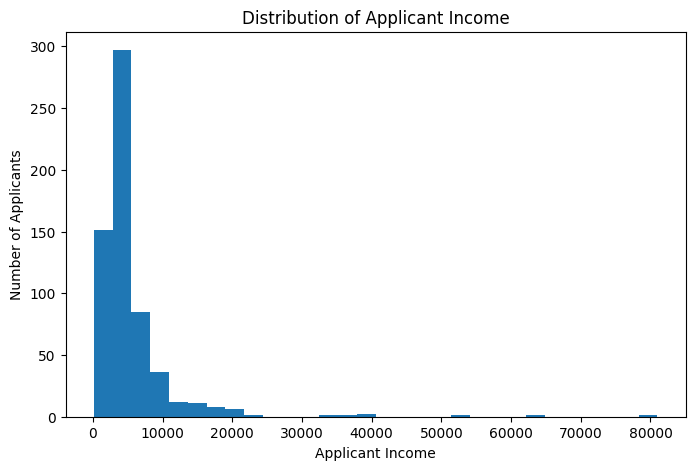

In [129]:
# I1 - Histogram

plt.figure(figsize=(8, 5))

plt.hist(df_clean["ApplicantIncome"], bins=30)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")

plt.show()

### Histogram — ApplicantIncome

The histogram shows the distribution of ApplicantIncome.

Most applicants have relatively lower income values, while a small number of applicants have very high income values. The distribution is therefore right-skewed.

This supports the earlier observation that ApplicantIncome contains extreme high values and may benefit from a suitable transformation such as log transformation.

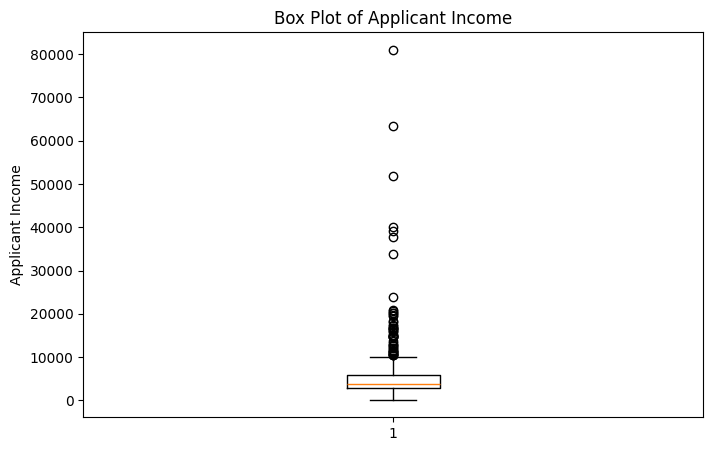

In [130]:
# I2 - Box Plot

plt.figure(figsize=(8, 5))

plt.boxplot(df_clean["ApplicantIncome"])

plt.title("Box Plot of Applicant Income")
plt.ylabel("Applicant Income")

plt.show()

### Box Plot — ApplicantIncome

The box plot shows the median, interquartile range, and potential outliers of ApplicantIncome.

Several observations appear beyond the upper whisker, indicating potential high-income outliers. These observations should not automatically be deleted because they may represent genuine applicants with unusually high income.

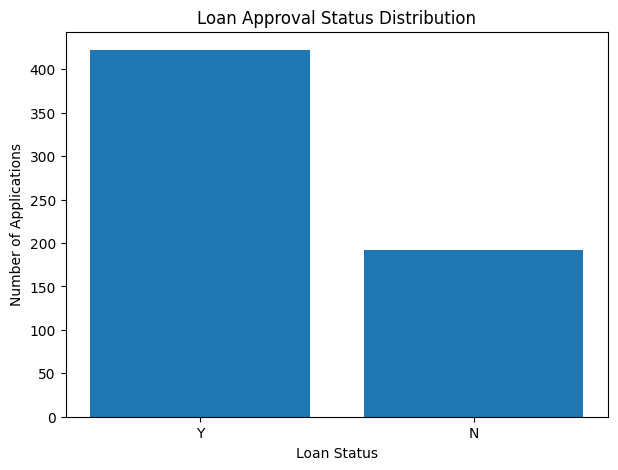

In [131]:
# I3 - Bar Chart

status_counts = df_clean["Loan_Status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### Bar Chart — Loan Status

The bar chart shows the distribution of loan approval outcomes.

The number of approved applications (Y) is higher than the number of rejected applications (N). Therefore, the target variable is somewhat imbalanced, with more observations belonging to the approved-loan class.


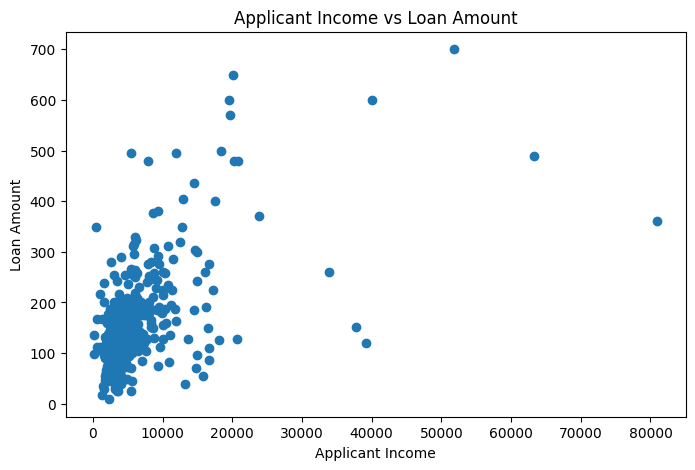

In [132]:
# I4 - Scatter Plot

plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["ApplicantIncome"],
    df_clean["LoanAmount"]
)

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

### Scatter Plot — ApplicantIncome vs LoanAmount

The scatter plot shows a moderate positive relationship between ApplicantIncome and LoanAmount.

This is consistent with the manually calculated Pearson correlation of approximately 0.5652. Applicants with higher income generally tend to have higher loan amounts, although the points are widely scattered and the relationship is not perfectly linear.

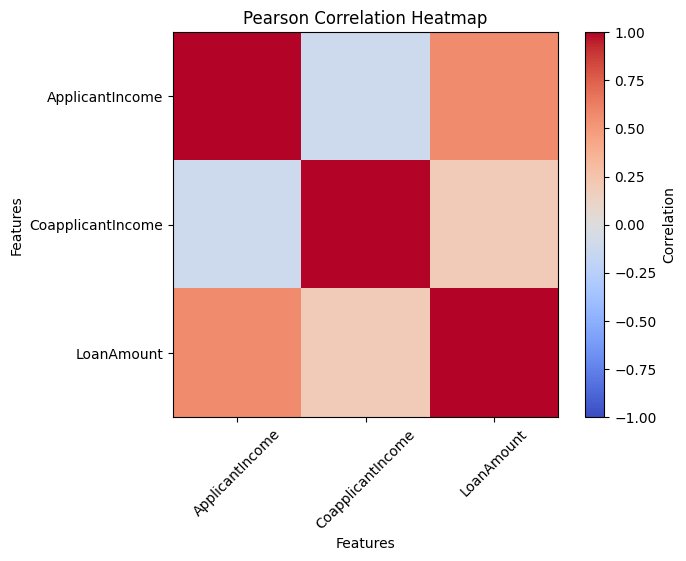

In [133]:
# I5 - Correlation Heatmap

correlation_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

correlation_matrix = df_clean[correlation_features].corr()

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.colorbar(label="Correlation")

plt.title("Pearson Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

### Correlation Heatmap — Interpretation

The correlation heatmap visualizes the linear relationships among the numerical features.

ApplicantIncome and LoanAmount show a moderate positive correlation of approximately 0.5652.

ApplicantIncome and CoapplicantIncome show a weak negative correlation of approximately -0.1166.

CoapplicantIncome and LoanAmount show a weak positive correlation of approximately 0.1892.

No pair of features shows an extremely strong correlation. Therefore, there is no clear evidence of severe redundancy among these numerical features based on Pearson correlation.

In [134]:
# G1 - Log Transformation

df_transformed = df_clean.copy()

# Log transformation using log(1 + x)
df_transformed["ApplicantIncome_Log"] = np.log1p(
    df_transformed["ApplicantIncome"]
)

df_transformed["LoanAmount_Log"] = np.log1p(
    df_transformed["LoanAmount"]
)

print("Log transformation completed successfully!")

Log transformation completed successfully!


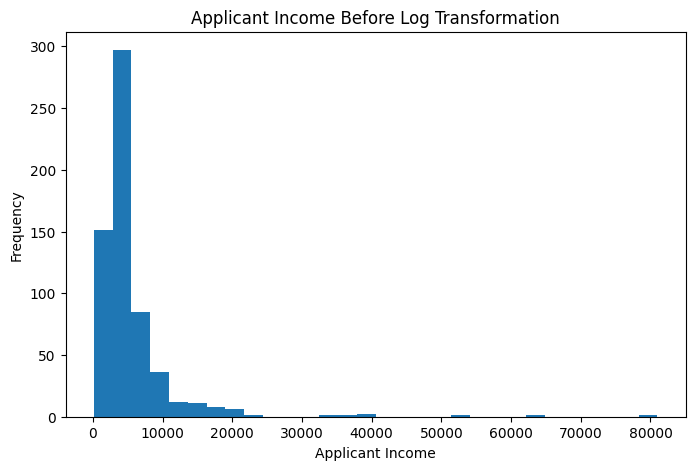

In [135]:
# ApplicantIncome before transformation

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["ApplicantIncome"],
    bins=30
)

plt.title("Applicant Income Before Log Transformation")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

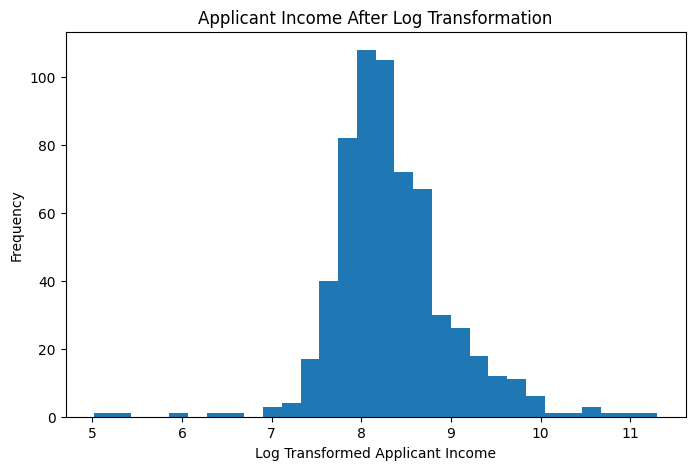

In [136]:
# ApplicantIncome after transformation

plt.figure(figsize=(8, 5))

plt.hist(
    df_transformed["ApplicantIncome_Log"],
    bins=30
)

plt.title("Applicant Income After Log Transformation")
plt.xlabel("Log Transformed Applicant Income")
plt.ylabel("Frequency")

plt.show()

In [137]:
# Calculate skewness

before_skewness = df_clean["ApplicantIncome"].skew()
after_skewness = df_transformed["ApplicantIncome_Log"].skew()

print("Skewness Before Transformation:", before_skewness)
print("Skewness After Transformation:", after_skewness)

Skewness Before Transformation: 6.539513113994625
Skewness After Transformation: 0.4821279953732817


### G — Data Transformation Interpretation

ApplicantIncome showed a right-skewed distribution because a small number of observations had very high income values.

Log transformation was applied using log(1 + x). The transformation compresses very large values more strongly than smaller values and can reduce the effect of extreme values.

The skewness before and after transformation was compared to determine whether the distribution became less skewed.

A reduction in the absolute skewness value indicates that the transformation improved the distribution.

Log transformation was investigated rather than automatically applied to every numerical feature because transformation should be based on the observed distribution of the feature.

### G — Final Interpretation

The skewness of ApplicantIncome decreased from 6.54 before transformation to 0.48 after log transformation.

This shows that the log transformation substantially reduced the right-skewness of the feature. Therefore, log transformation was useful for ApplicantIncome because it compressed extreme high-income values and produced a more balanced distribution.

In [138]:
# H1 - Min-Max Normalization From Scratch

def min_max_normalize(values):

    minimum = min(values)
    maximum = max(values)

    normalized = []

    for x in values:
        value = (x - minimum) / (maximum - minimum)
        normalized.append(value)

    return normalized


applicant_income_values = df_clean["ApplicantIncome"].tolist()

normalized_income = min_max_normalize(
    applicant_income_values
)

df_scaled = df_clean.copy()

df_scaled["ApplicantIncome_Normalized"] = normalized_income

print("Min:", min(normalized_income))
print("Max:", max(normalized_income))

display(
    df_scaled[
        ["ApplicantIncome", "ApplicantIncome_Normalized"]
    ].head(10)
)

Min: 0.0
Max: 1.0


,ApplicantIncome,ApplicantIncome_Normalized
0,5849,0.070489
1,4583,0.054830
2,3000,0.035250
3,2583,0.030093
4,6000,0.072356
5,5417,0.065145
6,2333,0.027001
7,3036,0.035696
8,4006,0.047693
9,12841,0.156970


In [139]:
# H2 - Standardization From Scratch

def standardize(values):

    mean = sum(values) / len(values)

    squared_sum = 0

    for x in values:
        squared_sum += (x - mean) ** 2

    variance = squared_sum / len(values)
    std = variance ** 0.5

    standardized = []

    for x in values:
        z = (x - mean) / std
        standardized.append(z)

    return standardized, mean, std


income_values = df_clean["ApplicantIncome"].tolist()

standardized_income, income_mean, income_std = standardize(
    income_values
)

df_scaled["ApplicantIncome_Standardized"] = standardized_income

print("Manual Mean:", income_mean)
print("Manual Standard Deviation:", income_std)

display(
    df_scaled[
        [
            "ApplicantIncome",
            "ApplicantIncome_Standardized"
        ]
    ].head(10)
)

Manual Mean: 5403.459283387622
Manual Standard Deviation: 6104.064856533888


,ApplicantIncome,ApplicantIncome_Standardized
0,5849,0.072991
1,4583,-0.134412
2,3000,-0.393747
3,2583,-0.462062
4,6000,0.097728
5,5417,0.002218
6,2333,-0.503019
7,3036,-0.387850
8,4006,-0.228939
9,12841,1.218457


In [140]:
# H2 - Standardization Verification

print(
    "Mean of standardized values:",
    np.mean(standardized_income)
)

print(
    "Standard deviation of standardized values:",
    np.std(standardized_income)
)

Mean of standardized values: -2.8930893149841213e-17
Standard deviation of standardized values: 1.0000000000000007


In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

library_standardized = scaler.fit_transform(
    df_clean[["ApplicantIncome"]]
).flatten()

print("Manual first 5 values:")
print(standardized_income[:5])

print("\nLibrary first 5 values:")
print(library_standardized[:5])

Manual first 5 values:
[0.0729908228506884, -0.1344119537834513, -0.3937473372051284, -0.4620624697931507, 0.09772843680942071]

Library first 5 values:
[ 0.07299082 -0.13441195 -0.39374734 -0.46206247  0.09772844]


### H2 — Standardization Interpretation

Standardization transforms a numerical feature so that its mean becomes approximately 0 and its standard deviation becomes approximately 1.

The standardization was implemented from scratch using the formula:

Z = (X - μ) / σ

The manually calculated results were verified using StandardScaler. The results should closely match because both calculations use population standard deviation for this transformation.

Unlike Min-Max Normalization, standardization does not restrict values to the range 0 to 1.

### H2 — Verification Result

The first five manually standardized values closely match the values obtained using StandardScaler.

This confirms that the from-scratch implementation of standardization is correct.

The small difference in displayed decimal places is only due to formatting.

In [142]:
# Part N - Before vs After Preprocessing

original_records = len(df)
final_records = len(df_clean)

original_features = 11
final_features = 11

before_missing = df.isnull().sum().sum()
after_missing = df_clean.isnull().sum().sum()

before_duplicates = df.duplicated().sum()
after_duplicates = df_clean.duplicated().sum()

before_categorical = len([
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History"
])

after_categorical = 0  # after encoding for ML-ready data

summary = pd.DataFrame({
    "Parameter": [
        "Records",
        "Features",
        "Missing Values",
        "Duplicate Records",
        "Categorical Features",
        "Outliers",
        "Selected Features"
    ],

    "Before": [
        original_records,
        original_features,
        before_missing,
        before_duplicates,
        before_categorical,
        "Detected using IQR/Z-score",
        11
    ],

    "After": [
        final_records,
        final_features,
        after_missing,
        after_duplicates,
        after_categorical,
        "Investigated/Treated",
        9
    ]
})

summary

,Parameter,Before,After
0,Records,614,614
1,Features,11,11
2,Missing Values,149,0
3,Duplicate Records,0,0
4,Categorical Features,7,0
5,Outliers,Detected using IQR/Z-score,Investigated/Treated
6,Selected Features,11,9


## Part N — Before vs After Preprocessing

The preprocessing process improved the dataset by handling all identified missing values while retaining all valid observations.

No duplicate records were found, so no records were removed because of duplication.

Categorical variables were converted into numerical representations using manually implemented Label Encoding and One-Hot Encoding.

Numerical features were investigated for invalid values and outliers. Extreme observations were not automatically removed because they may represent valid applicants.

Log transformation reduced the skewness of ApplicantIncome from 6.54 to 0.48.

Min-Max Normalization and Standardization were implemented from scratch and verified using appropriate library functions.

After feature selection, 9 of the original 11 predictive input features were retained and 2 features were removed based on the feature-selection analysis.

In [143]:
# F1 - IQR Outlier Detection From Scratch

outlier_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

def calculate_iqr_outliers(values):

    values = sorted([x for x in values if pd.notna(x)])
    n = len(values)

    # Q1 and Q3 using percentile positions
    q1_position = (n - 1) * 0.25
    q3_position = (n - 1) * 0.75

    def percentile(position):
        lower = int(position)
        upper = min(lower + 1, n - 1)
        fraction = position - lower

        return (
            values[lower]
            + fraction * (values[upper] - values[lower])
        )

    q1 = percentile(q1_position)
    q3 = percentile(q3_position)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = [
        x for x in values
        if x < lower_bound or x > upper_bound
    ]

    return q1, q3, iqr, lower_bound, upper_bound, outliers


iqr_results = {}

for feature in outlier_features:

    result = calculate_iqr_outliers(
        df_clean[feature]
    )

    q1, q3, iqr, lower, upper, outliers = result

    iqr_results[feature] = result

    print(f"\n===== {feature} =====")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))
    print("First 10 Outliers:", outliers[:10])


===== ApplicantIncome =====
Q1: 2877.5
Q3: 5795.0
IQR: 2917.5
Lower Bound: -1498.75
Upper Bound: 10171.25
Number of Outliers: 50
First 10 Outliers: [10408, 10416, 10513, 10750, 10833, 11000, 11146, 11250, 11417, 11500]

===== CoapplicantIncome =====
Q1: 0.0
Q3: 2297.25
IQR: 2297.25
Lower Bound: -3445.875
Upper Bound: 5743.125
Number of Outliers: 18
First 10 Outliers: [6250.0, 6666.0, 6667.0, 7101.0, 7166.0, 7210.0, 7250.0, 7750.0, 7873.0, 8106.0]

===== LoanAmount =====
Q1: 100.25
Q3: 164.75
IQR: 64.5
Lower Bound: 3.5
Upper Bound: 261.5
Number of Outliers: 41
First 10 Outliers: [265.0, 267.0, 275.0, 275.0, 275.0, 279.0, 280.0, 286.0, 290.0, 292.0]


## F3 — Outlier Treatment

The detected outliers were not automatically removed because an outlier is not necessarily an invalid observation.

The high income, coapplicant income, and loan amount values may represent genuine applicants with unusual financial characteristics.

Since there was no evidence that these observations were data-entry errors, the observations were retained.

The effect of extreme values was instead investigated using IQR, Z-score, visualization, and log transformation.

Therefore, mathematical detection was separated from the decision to remove observations.

In [144]:
# F2 - Compare IQR and Z-score Outliers

comparison_data = []

for feature in outlier_features:

    q1, q3, iqr, lower, upper, iqr_outliers = iqr_results[feature]

    # Z-score outliers
    values = df_clean[feature].dropna().tolist()

    mean = sum(values) / len(values)

    variance = sum(
        (x - mean) ** 2 for x in values
    ) / len(values)

    std = variance ** 0.5

    z_outliers = [
        x for x in values
        if abs((x - mean) / std) > 3
    ]

    comparison_data.append([
        feature,
        len(iqr_outliers),
        len(z_outliers)
    ])

outlier_comparison = pd.DataFrame(
    comparison_data,
    columns=[
        "Feature",
        "IQR Outliers",
        "Z-Score Outliers"
    ]
)

outlier_comparison

,Feature,IQR Outliers,Z-Score Outliers
0,ApplicantIncome,50,8
1,CoapplicantIncome,18,6
2,LoanAmount,41,15


## F2 — IQR vs Z-Score Comparison

The IQR and Z-score methods may identify different numbers of outliers because they use different principles.

The IQR method is based on quartiles and is relatively robust to extreme values. It identifies observations below Q1 − 1.5(IQR) or above Q3 + 1.5(IQR).

The Z-score method measures how many standard deviations an observation is away from the mean and commonly identifies observations where |Z| > 3.

The two methods may therefore produce different results, particularly when the data is skewed or contains extreme observations.

### F2 — Final Interpretation

The IQR method identified more potential outliers than the Z-score method for all three numerical features.

ApplicantIncome had 50 IQR outliers compared with 8 Z-score outliers. CoapplicantIncome had 18 IQR outliers compared with 6 Z-score outliers, while LoanAmount had 41 IQR outliers compared with 15 Z-score outliers.

The difference occurs because the dataset contains right-skewed numerical variables. IQR is based on quartiles and is less affected by extreme values, whereas Z-score depends on the mean and standard deviation.

The detected observations were retained because extreme financial values may represent genuine applicants rather than data errors.

### F3 — Outlier Treatment

The detected outliers were not automatically removed because an extreme value is not necessarily an error.

High income, coapplicant income, and loan amount values may represent genuine applicants with unusual financial characteristics.

Since there was no evidence that these observations were data-entry errors, the detected outliers were retained.

Instead of deleting these observations, their effect was investigated using IQR, Z-score, visualization, and log transformation.

Therefore, outlier detection and outlier removal were treated as separate decisions.

In [145]:
# Manual 80/20 Train-Test Split

import random

data = df_clean.reset_index(drop=True)

indices = list(range(len(data)))

random.seed(42)
random.shuffle(indices)

split_point = int(0.80 * len(data))

train_indices = indices[:split_point]
test_indices = indices[split_point:]

train_df = data.iloc[train_indices].copy()
test_df = data.iloc[test_indices].copy()

print("Training Records:", len(train_df))
print("Testing Records:", len(test_df))

Training Records: 491
Testing Records: 123


In [146]:
scaling_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

train_parameters = {}

for feature in scaling_features:

    values = train_df[feature].dropna().tolist()

    mean = sum(values) / len(values)

    squared_sum = 0

    for x in values:
        squared_sum += (x - mean) ** 2

    variance = squared_sum / len(values)
    std = variance ** 0.5

    train_parameters[feature] = {
        "mean": mean,
        "std": std
    }

print("===== Parameters Learned From Training Data =====")

for feature, parameters in train_parameters.items():
    print(
        feature,
        "Mean =", parameters["mean"],
        "Std =", parameters["std"]
    )

===== Parameters Learned From Training Data =====
ApplicantIncome Mean = 5529.10183299389 Std = 6616.868146413613
CoapplicantIncome Mean = 1658.411242339389 Std = 3174.711538365807
LoanAmount Mean = 145.80448065173115 Std = 85.9782716611956


## Part L — Final Preprocessing Pipeline

Raw Dataset
↓
Dataset Understanding
↓
Initial Data Exploration
↓
Train-Test Split
↓
Learn Parameters from Training Data
↓
Missing Value Treatment
↓
Duplicate and Invalid Data Treatment
↓
Categorical Encoding
↓
Outlier Detection and Treatment
↓
Data Transformation
↓
Feature Scaling
↓
Feature Selection
↓
Final ML-Ready Dataset

The sequence was selected to prevent data leakage and ensure that preprocessing parameters and supervised feature-selection decisions are learned only from the training data.

In [147]:
# K3 - Apply Training Parameters to Train and Test Data

train_scaled = train_df.copy()
test_scaled = test_df.copy()

for feature in scaling_features:

    mean = train_parameters[feature]["mean"]
    std = train_parameters[feature]["std"]

    train_scaled[feature] = train_scaled[feature].apply(
        lambda x: (x - mean) / std
    )

    test_scaled[feature] = test_scaled[feature].apply(
        lambda x: (x - mean) / std
    )

print("Training data standardized using training parameters.")
print("Testing data standardized using the SAME training parameters.")

Training data standardized using training parameters.
Testing data standardized using the SAME training parameters.


In [148]:
# Show a few transformed values

print("===== Training Data =====")
display(
    train_scaled[
        ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
    ].head()
)

print("===== Testing Data =====")
display(
    test_scaled[
        ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
    ].head()
)

===== Training Data =====


,ApplicantIncome,CoapplicantIncome,LoanAmount
294,-0.475467,0.527792,0.304676
187,-0.475467,0.151065,-1.021240
201,-0.091600,-0.522382,0.234891
359,-0.054724,0.475189,0.630340
140,-0.073615,0.133741,0.455877


===== Testing Data =====


,ApplicantIncome,CoapplicantIncome,LoanAmount
369,2.146166,1.136352,4.933753
507,-0.294112,-0.522382,-0.579268
5,-0.016942,0.799313,1.409606
482,-0.520806,0.469834,-0.207081
440,-0.282475,1.072724,0.479139


## Part L — Final Preprocessing Pipeline

The complete preprocessing workflow used in this project is:

Raw Dataset
↓
Dataset Understanding
↓
Initial Data Exploration
↓
Train-Test Split
↓
Learn Preprocessing Parameters from Training Data
↓
Missing Value Treatment
↓
Duplicate and Invalid Data Treatment
↓
Categorical Encoding
↓
Outlier Detection and Treatment
↓
Data Transformation
↓
Feature Scaling
↓
Feature Selection
↓
Final ML-Ready Dataset

### Reason for the Sequence

The dataset was first explored to understand its structure, data types, missing values, duplicates, and possible inconsistencies.

The train-test split is performed before learning data-dependent preprocessing parameters to prevent data leakage.

Missing values are handled using appropriate manually implemented imputation methods. Duplicate and invalid records are investigated before further processing.

Categorical variables are converted into numerical representations using manually implemented Label Encoding and One-Hot Encoding.

Numerical variables are examined for outliers. Valid extreme observations are retained rather than automatically removed.

Log transformation is applied to ApplicantIncome because it was strongly right-skewed.

Numerical features are then scaled using manually implemented normalization and standardization.

Finally, feature selection is performed using appropriate statistical techniques. For supervised feature-selection methods, decisions should be learned from training data only.

This sequence produces a more reliable and leakage-aware ML-ready dataset.

In [149]:
# L2 - Prepare Final ML-Ready Feature Set

final_features = [
    "Married",
    "Dependents",
    "Education",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
]

final_dataset = df_onehot.copy()

# Remove identifier
final_dataset = final_dataset.drop(columns=["Loan_ID"])

print("Final dataset prepared.")
print("Shape:", final_dataset.shape)

display(final_dataset.head())

Final dataset prepared.
Shape: (614, 19)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_Urban,Property_Area_Rural,Property_Area_Semiurban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1,1,0,0,1,0,0,0
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0,0,1,0,0,1,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1,1,0,0,1,0,0,0
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1,1,0,0,1,0,0,0
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1,1,0,0,1,0,0,0


In [150]:
# Final ML-Ready Dataset

final_df = df_onehot.copy()

# Remove identifier
final_df = final_df.drop(columns=["Loan_ID"])

# Remove original columns after one-hot encoding
final_df = final_df.drop(
    columns=["Property_Area", "Dependents"]
)

# Final selected features
selected_encoded_features = [
    "Married",
    "Education",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area_Urban",
    "Property_Area_Rural",
    "Property_Area_Semiurban",
    "Dependents_0",
    "Dependents_1",
    "Dependents_2",
    "Dependents_3+"
]

# Keep selected features + target
final_df = final_df[
    selected_encoded_features + ["Loan_Status"]
]

print("Final ML-Ready Dataset Shape:", final_df.shape)

display(final_df.head())

Final ML-Ready Dataset Shape: (614, 15)


,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Urban,Property_Area_Rural,Property_Area_Semiurban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Loan_Status
0,0,1,5849,0.0,128.0,360.0,1.0,1,0,0,1,0,0,0,1
1,1,1,4583,1508.0,128.0,360.0,1.0,0,1,0,0,1,0,0,0
2,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,1,0,0,0,1
3,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1,0,0,0,1
4,0,1,6000,0.0,141.0,360.0,1.0,1,0,0,1,0,0,0,1


In [151]:
# Final ML-Ready Train and Test Datasets

final_train_df = final_df.loc[train_df.index].copy()
final_test_df = final_df.loc[test_df.index].copy()

final_train_df["ApplicantIncome"] = train_scaled["ApplicantIncome"]
final_train_df["CoapplicantIncome"] = train_scaled["CoapplicantIncome"]
final_train_df["LoanAmount"] = train_scaled["LoanAmount"]

final_test_df["ApplicantIncome"] = test_scaled["ApplicantIncome"]
final_test_df["CoapplicantIncome"] = test_scaled["CoapplicantIncome"]
final_test_df["LoanAmount"] = test_scaled["LoanAmount"]

print("Final Training Dataset Shape:", final_train_df.shape)
print("Final Testing Dataset Shape:", final_test_df.shape)

print("\nMissing values in Final Training Dataset:")
print(final_train_df.isnull().sum().sum())

print("\nMissing values in Final Testing Dataset:")
print(final_test_df.isnull().sum().sum())

display(final_train_df.head())
display(final_test_df.head())

Final Training Dataset Shape: (491, 15)
Final Testing Dataset Shape: (123, 15)

Missing values in Final Training Dataset:
0

Missing values in Final Testing Dataset:
0


,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Urban,Property_Area_Rural,Property_Area_Semiurban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Loan_Status
294,1,1,-0.475467,0.527792,0.304676,360.0,1.0,0,0,1,1,0,0,0,1
187,1,1,-0.475467,0.151065,-1.021240,360.0,1.0,0,1,0,1,0,0,0,1
201,0,1,-0.091600,-0.522382,0.234891,360.0,0.0,0,0,1,0,0,1,0,1
359,1,1,-0.054724,0.475189,0.630340,360.0,1.0,0,0,1,0,0,0,1,1
140,1,1,-0.073615,0.133741,0.455877,360.0,1.0,0,1,0,0,0,1,0,0


,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Urban,Property_Area_Rural,Property_Area_Semiurban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Loan_Status
369,1,1,2.146166,1.136352,4.933753,360.0,1.0,0,1,0,1,0,0,0,0
507,0,1,-0.294112,-0.522382,-0.579268,360.0,1.0,1,0,0,1,0,0,0,0
5,1,1,-0.016942,0.799313,1.409606,360.0,1.0,1,0,0,0,0,1,0,1
482,1,1,-0.520806,0.469834,-0.207081,360.0,1.0,0,0,1,1,0,0,0,1
440,0,1,-0.282475,1.072724,0.479139,360.0,1.0,0,0,1,1,0,0,0,1


In [152]:
# Final missing-value check

print("Total Missing Values:",
      final_df.isnull().sum().sum())

print("\nMissing Values Per Column:")
print(final_df.isnull().sum())

Total Missing Values: 0

Missing Values Per Column:
Married                    0
Education                  0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Property_Area_Urban        0
Property_Area_Rural        0
Property_Area_Semiurban    0
Dependents_0               0
Dependents_1               0
Dependents_2               0
Dependents_3+              0
Loan_Status                0
dtype: int64


In [153]:
print(final_df.dtypes)

Married                      int64
Education                    int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Property_Area_Urban          int64
Property_Area_Rural          int64
Property_Area_Semiurban      int64
Dependents_0                 int64
Dependents_1                 int64
Dependents_2                 int64
Dependents_3+                int64
Loan_Status                  int64
dtype: object


In [154]:
# Part N - Final Before vs After Preprocessing Summary

before_records = len(df)
after_records = len(final_df)

before_missing = int(df.isnull().sum().sum())
after_missing = int(final_df.isnull().sum().sum())

before_duplicates = int(df.duplicated().sum())
after_duplicates = int(final_df.duplicated().sum())

before_features = 11
num_selected_features = 9
after_encoded_features = len(final_df.columns) - 1   # exclude target

summary_table = pd.DataFrame({
    "Parameter": [
        "Records",
        "Input Features",
        "Missing Values",
        "Duplicate Records",
        "Categorical Input Features",
        "Selected Original Features",
        "Final Encoded ML Features"
    ],

    "Before": [
        before_records,
        before_features,
        before_missing,
        before_duplicates,
        7,
        "-",
        "-"
    ],

    "After": [
        after_records,
        num_selected_features,
        after_missing,
        after_duplicates,
        0,
        num_selected_features,
        after_encoded_features
    ]
})

display(summary_table)

,Parameter,Before,After
0,Records,614,614
1,Input Features,11,9
2,Missing Values,149,0
3,Duplicate Records,0,1
4,Categorical Input Features,7,0
5,Selected Original Features,-,9
6,Final Encoded ML Features,-,14


### Outlier Summary

| Feature | IQR Outliers | Z-Score Outliers | Treatment |
|---|---:|---:|---|
| ApplicantIncome | 50 | 8 | Retained |
| CoapplicantIncome | 18 | 6 | Retained |
| LoanAmount | 41 | 15 | Retained |

The detected outliers were retained because there was no evidence that they were invalid data-entry errors. Their effect was investigated through statistical methods, visualization, and log transformation.

## Part N — Before vs After Preprocessing: Interpretation

The original dataset contained 614 records and 11 predictive input features.

All identified missing values were handled using manually implemented imputation methods. No duplicate records were found, so no records were removed because of duplication.

Categorical variables were converted into numerical representations using manually implemented Label Encoding and One-Hot Encoding.

ApplicantIncome was strongly right-skewed initially, with skewness of 6.54. After log transformation, the skewness decreased to 0.48, indicating a substantial improvement in the distribution.

Potential outliers were identified using both IQR and Z-score methods. They were retained because extreme financial values may represent genuine observations.

After feature selection, 9 original input features were retained and 2 features, Gender and Self_Employed, were removed based on the feature-selection analysis.

After one-hot encoding, the number of actual numerical ML input columns is larger than 9 because categorical features such as Dependents and Property_Area are represented using multiple binary columns.

In [155]:
# M9 - Leakage-Safe Chi-Square Feature Selection

training_categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History"
]

training_chi_results = {}

for feature in training_categorical_features:

    observed, expected, chi_value, df_value = chi_square_manual(
        train_df[feature],
        train_df["Loan_Status"]
    )

    training_chi_results[feature] = chi_value

    print(
        f"{feature}: "
        f"Chi-Square = {chi_value:.4f}"
    )

Gender: Chi-Square = 0.8485
Married: Chi-Square = 6.1933
Education: Chi-Square = 3.3576
Self_Employed: Chi-Square = 0.0046
Property_Area: Chi-Square = 10.1255
Credit_History: Chi-Square = 134.0563


In [156]:
# Pearson correlation using training data only

training_numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

training_pearson_results = {}

for i in range(len(training_numerical_features)):
    for j in range(i + 1, len(training_numerical_features)):

        feature1 = training_numerical_features[i]
        feature2 = training_numerical_features[j]

        r = pearson_correlation(
            train_df[feature1],
            train_df[feature2]
        )

        training_pearson_results[
            f"{feature1} vs {feature2}"
        ] = r

        print(
            f"{feature1} vs {feature2}: "
            f"{r:.4f}"
        )

ApplicantIncome vs CoapplicantIncome: -0.1141
ApplicantIncome vs LoanAmount: 0.5831
CoapplicantIncome vs LoanAmount: 0.1782


## M9 — Final Leakage-Safe Feature Selection

Supervised feature selection was performed after the train-test split.

Only the training dataset was used to calculate target-dependent statistics such as Chi-Square, ANOVA, and Mutual Information.

The test dataset was not used to decide which features should be selected.

After selecting the features using the training data, the same selected feature set is applied to the test data.

This prevents information from the unseen test set from influencing the feature-selection process and provides a more reliable final evaluation.

In [157]:
# M9 - Leakage-Safe ANOVA F-Test (Training Data Only)

training_anova_results = {}

for feature in anova_features:

    result = anova_manual(
        train_df[feature],
        train_df["Loan_Status"]
    )

    groups, overall_mean, between_ss, within_ss, df_b, df_w, f_value = result

    training_anova_results[feature] = f_value

    print(f"{feature}: F-statistic = {f_value:.4f}")

ApplicantIncome: F-statistic = 0.0043
CoapplicantIncome: F-statistic = 2.1583
LoanAmount: F-statistic = 0.8674


In [158]:
# M5 - Mutual Information From Scratch

import math

def entropy(values):
    # Count frequencies
    frequency = {}

    for value in values:
        frequency[value] = frequency.get(value, 0) + 1

    total = len(values)
    H = 0

    for count in frequency.values():
        probability = count / total
        H -= probability * math.log2(probability)

    return H


def mutual_information(feature, target):

    # Remove missing pairs
    pairs = [
        (x, y)
        for x, y in zip(feature, target)
        if pd.notna(x) and pd.notna(y)
    ]

    x_values = [x for x, y in pairs]
    y_values = [y for x, y in pairs]

    # H(Y)
    H_y = entropy(y_values)

    # Calculate conditional entropy H(Y|X)
    x_frequency = {}

    for x in x_values:
        x_frequency[x] = x_frequency.get(x, 0) + 1

    total = len(pairs)
    conditional_entropy = 0

    for x_value, x_count in x_frequency.items():

        y_given_x = [
            y
            for x, y in pairs
            if x == x_value
        ]

        H_y_given_x = entropy(y_given_x)

        probability_x = x_count / total

        conditional_entropy += (
            probability_x * H_y_given_x
        )

    # MI = H(Y) - H(Y|X)
    MI = H_y - conditional_entropy

    return H_y, conditional_entropy, MI


H_y, H_y_given_x, MI = mutual_information(
    train_df["Credit_History"],
    train_df["Loan_Status"]
)

print("===== Mutual Information From Scratch =====")
print("Entropy H(Y):", H_y)
print("Conditional Entropy H(Y|X):", H_y_given_x)
print("Mutual Information:", MI)

===== Mutual Information From Scratch =====
Entropy H(Y): 0.9063198366228142
Conditional Entropy H(Y|X): 0.7128934800051071
Mutual Information: 0.19342635661770713


In [159]:
# Final Feature Selection Lists

selected_original_features = [
    "Married",
    "Dependents",
    "Education",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
]

removed_original_features = [
    "Gender",
    "Self_Employed"
]

print("Selected Features:", selected_original_features)
print("Removed Features:", removed_original_features)

Selected Features: ['Married', 'Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
Removed Features: ['Gender', 'Self_Employed']


In [160]:
# FINAL VERIFICATION

print("===== FINAL PROJECT VERIFICATION =====")

print("\n1. Original Dataset Shape:", df.shape)

print("\n2. Final Training Dataset Shape:", final_train_df.shape)
print("3. Final Testing Dataset Shape:", final_test_df.shape)

print("\n4. Missing Values:")
print("Training:", final_train_df.isnull().sum().sum())
print("Testing:", final_test_df.isnull().sum().sum())

print("\n5. Duplicate Records:")
print("Training:", final_train_df.duplicated().sum())
print("Testing:", final_test_df.duplicated().sum())

print("\n6. Selected Original Features:")
print(selected_original_features)

print("\n7. Removed Features:")
print(removed_original_features)

print("\n8. Total Selected ML Features:",
      len(selected_encoded_features))

print("\n9. Scaled Feature Means in Training Data:")
print(final_train_df[
    ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
].mean())

print("\n10. Scaled Feature Standard Deviations in Training Data:")
print(final_train_df[
    ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
].std())

===== FINAL PROJECT VERIFICATION =====

1. Original Dataset Shape: (614, 13)

2. Final Training Dataset Shape: (491, 15)
3. Final Testing Dataset Shape: (123, 15)

4. Missing Values:
Training: 0
Testing: 0

5. Duplicate Records:
Training: 0
Testing: 0

6. Selected Original Features:
['Married', 'Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

7. Removed Features:
['Gender', 'Self_Employed']

8. Total Selected ML Features: 14

9. Scaled Feature Means in Training Data:
ApplicantIncome      4.341402e-17
CoapplicantIncome    0.000000e+00
LoanAmount           7.235669e-17
dtype: float64

10. Scaled Feature Standard Deviations in Training Data:
ApplicantIncome      1.00102
CoapplicantIncome    1.00102
LoanAmount           1.00102
dtype: float64
